# 📊 Análisis Exploratorio de Datos — REM20

> **Dataset:** Indicadores de Hospitalización REM20  
> **Cubre:** Inspección inicial · Clasificación de variables · Nulos · Duplicados · Rangos · Valores únicos · Estadística descriptiva · Outliers · Correlaciones

## 1. Carga del Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style='whitegrid', palette='muted')  
# Configura el estilo general de los gráficos de seaborn:
# - 'whitegrid': fondo blanco con grilla (útil para visualizar valores)
# - 'muted': paleta de colores suaves (menos saturados)

plt.rcParams['figure.dpi'] = 120  
# Ajusta la resolución de las figuras (dots per inch)
# Mayor valor = imagen más nítida (pero más pesada)

plt.rcParams['axes.titlesize'] = 13  
# Define el tamaño de la fuente de los títulos de los gráficos

plt.rcParams['axes.labelsize'] = 11  
# Define el tamaño de la fuente de las etiquetas de los ejes (X e Y)

pd.set_option('display.max_columns', None)  
# Configura pandas para mostrar todas las columnas de un DataFrame
# (None = sin límite, útil cuando hay muchas columnas)

df = pd.read_csv("C:/Users/bravo/OneDrive/Escritorio/Analisis de datos/proyecto_analisis_datos/data/indicadores_rem20_20260225.csv", 
                 sep=';')

df["AREA_FUNCIONAL"] = df["AREA_FUNCIONAL"].str.strip()

print(f'Periodo: {df["PERIODO"].min()}-{df["PERIODO"].max()}')

display(df.head())

# Paleta de colores por nivel de complejidad (definida globalmente para reusar en P2, P4 y P5)
palette = {'Alta complejidad': 'tomato', 'Media complejidad': 'steelblue', 'Baja complejidad': 'seagreen'}

Periodo: 2014-2025


,PERIODO,TIPO_PERTENENCIA,COD_SSS,GLOSA_SSS,CODIGO_ESTABLECIMIENTO,ESTABLECIMIENTO,COD_AREA_FUNCIONAL,AREA_FUNCIONAL,MES,DIAS_CAMAS_OCUPADAS,DIAS_CAMAS_DISPONIBLES,DIAS_ESTADA,NUMERO_EGRESOS,EGRESOS_FALLECIDOS,TRASLADOS,INDICE_OCUPACIONAL,PROMEDIO_CAMAS_DISPONIBLE,PROMEDIO_DIAS_ESTADA,LETALIDAD,INDICE_ROTACION
0,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,1,139,186,115,9,7,12,74.73,6.0,12.78,77.78,1.50
1,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,2,103,168,164,7,4,21,61.31,6.0,23.43,57.14,1.17
2,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,3,117,186,98,15,9,12,62.90,6.0,6.53,60.00,2.50
3,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,4,126,180,114,7,5,17,70.00,6.0,16.29,71.43,1.17
4,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,5,141,186,165,11,7,19,75.81,6.0,15.00,63.64,1.83


## 2. Inspección Inicial

In [2]:
# Mostramos el total de filas y columnas del dataset para tener una idea
# de su tamaño. Luego df.info() muestra el nombre de cada columna,
# cuántos valores no nulos tiene y el tipo de dato (int, float, object).
# Esto permite detectar rápidamente si hay columnas con datos faltantes
# o con tipos incorrectos (por ejemplo, una fecha guardada como texto).
print(f'Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas')

print("="*60)
df.info()

Dataset cargado: 159,788 filas | 20 columnas
<class 'pandas.DataFrame'>
RangeIndex: 159788 entries, 0 to 159787
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PERIODO                    159788 non-null  int64  
 1   TIPO_PERTENENCIA           159788 non-null  int64  
 2   COD_SSS                    159788 non-null  int64  
 3   GLOSA_SSS                  159788 non-null  str    
 4   CODIGO_ESTABLECIMIENTO     159788 non-null  int64  
 5   ESTABLECIMIENTO            159788 non-null  str    
 6   COD_AREA_FUNCIONAL         159788 non-null  int64  
 7   AREA_FUNCIONAL             159788 non-null  str    
 8   MES                        159788 non-null  int64  
 9   DIAS_CAMAS_OCUPADAS        159788 non-null  int64  
 10  DIAS_CAMAS_DISPONIBLES     159788 non-null  int64  
 11  DIAS_ESTADA                159788 non-null  int64  
 12  NUMERO_EGRESOS             159788 non-null  int64  


Resumen estadístico rápido de todas las variables numéricas del dataset.

In [3]:
# df.describe() calcula automáticamente las estadísticas descriptivas
# de todas las columnas numéricas: cuántos valores hay (count), la media,
# la desviación estándar, el mínimo, los percentiles 25/50/75 y el máximo.
# El .round(2) redondea a 2 decimales para que sea más legible.
# Con esto se puede ver de un vistazo si hay valores extremos o fuera de rango.
df.describe().round(2)

,PERIODO,TIPO_PERTENENCIA,COD_SSS,CODIGO_ESTABLECIMIENTO,COD_AREA_FUNCIONAL,MES,DIAS_CAMAS_OCUPADAS,DIAS_CAMAS_DISPONIBLES,DIAS_ESTADA,NUMERO_EGRESOS,EGRESOS_FALLECIDOS,TRASLADOS,INDICE_OCUPACIONAL,PROMEDIO_CAMAS_DISPONIBLE,PROMEDIO_DIAS_ESTADA,LETALIDAD,INDICE_ROTACION
count,159788.00,159788.0,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00
mean,2019.54,1.0,15.07,115481.38,404.58,6.50,552.21,705.12,546.02,75.12,2.44,19.59,63.98,23.16,19.00,7.74,2.87
std,3.43,0.0,7.85,9303.72,19.30,3.45,884.05,983.36,997.95,125.68,5.63,54.80,34.65,32.28,132.61,19.30,5.27
min,2014.00,1.0,1.00,101100.00,330.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2017.00,1.0,9.00,109100.00,403.00,4.00,81.00,180.00,61.00,7.00,0.00,0.00,43.53,6.00,2.97,0.00,0.89
50%,2020.00,1.0,15.00,115105.00,407.00,6.50,247.00,372.00,225.00,26.00,0.00,3.00,72.04,12.00,5.92,0.00,2.25
75%,2023.00,1.0,21.00,121114.00,414.00,9.00,626.00,818.00,600.00,85.00,2.00,18.00,89.21,27.00,12.72,4.67,4.00
max,2025.00,1.0,33.00,201319.00,429.00,12.00,14677.00,24800.00,96898.00,1700.00,138.00,2780.00,2700.00,800.00,18512.00,100.00,1116.00


## 3. Clasificación de Variables

### Identificadores y códigos

| Columna | Tipo | Justificación |
|---------|------|---------------|
| `CODIGO_ESTABLECIMIENTO` | Identificador numérico | Código interno, no tiene interpretación cuantitativa |
| `COD_SSS` | Identificador numérico | 29 códigos que representan servicios de salud, no magnitud |
| `COD_AREA_FUNCIONAL` | Identificador numérico | 29 códigos de área, versión numérica de `AREA_FUNCIONAL` |

### Temporales

| Columna | Tipo | Justificación |
|---------|------|---------------|
| `PERIODO` | Temporal | 12 valores: 2014–2025, funciona como eje de tiempo |
| `MES` | Temporal | 12 valores: 1–12, representa el mes del registro |

### Cualitativas nominales

| Columna | N° categorías | Justificación |
|---------|---------------|---------------|
| `GLOSA_SSS` | 32 | Nombres de servicios de salud, sin orden intrínseco |
| `ESTABLECIMIENTO` | 313 | Nombres de establecimientos hospitalarios, sin orden |
| `AREA_FUNCIONAL` | 31 | Áreas clínicas (UCI, Maternidad, etc.), sin jerarquía formal |
| `TIPO_PERTENENCIA` | 1 | **Constante** — único valor en todo el dataset, no aporta información |

### Cuantitativas discretas

Variables de conteo, siempre enteras, con cantidad de valores únicos acotada respecto al total de filas (159.788).

| Columna | Rango | Valores únicos | Justificación |
|---------|-------|----------------|---------------|
| `DIAS_CAMAS_OCUPADAS` | 0 – 14.677 | 5.434 | Conteo de días-cama ocupadas en el período |
| `DIAS_CAMAS_DISPONIBLES` | 0 – 24.800 | 5.713 | Conteo de días-cama disponibles en el período |
| `DIAS_ESTADA` | 0 – 96.898 | 5.598 | Suma de días de hospitalización por período |
| `NUMERO_EGRESOS` | 0 – 1.700 | 1.092 | Conteo de pacientes egresados |
| `EGRESOS_FALLECIDOS` | 0 – 138 | 102 | Subconjunto entero de egresos |
| `TRASLADOS` | 0 – 2.780 | 732 | Conteo de traslados entre establecimientos |

### Cuantitativas continuas

Variables calculadas como razones o promedios, almacenadas como `float64`, pueden tomar cualquier valor decimal dentro de su rango.

| Columna | Rango | Justificación |
|---------|-------|---------------|
| `INDICE_OCUPACIONAL` | 0 – 100% *(post limpieza)* | Razón porcentual: días cama ocupadas / días cama disponibles × 100 |
| `PROMEDIO_CAMAS_DISPONIBLE` | 0 – 800 | Promedio mensual de camas disponibles |
| `PROMEDIO_DIAS_ESTADA` | 0 – 18.512 | Promedio de días de estadía por egreso |
| `LETALIDAD` | 0 – 100% | Razón porcentual: egresos fallecidos / total egresos × 100 |
| `INDICE_ROTACION` | 0 – 1.116 *(pre limpieza)* | Egresos por cama disponible en el período |

> **Nota:** `INDICE_ROTACION` presenta un máximo de 1.116, lo que sugiere outliers similares a los detectados en `INDICE_OCUPACIONAL`. Se recomienda aplicar el mismo criterio de limpieza por rango teórico antes de usarlo en análisis.

In [4]:
# Imprimimos el mínimo, máximo y número de valores únicos de cada variable numérica.
# Esto sirve para detectar valores imposibles: por ejemplo, un índice ocupacional
# negativo o superior al 100% es un error que hay que corregir antes del análisis.
# La cantidad de valores únicos (nunique) también da una idea de si la variable
# es continua (muchos valores únicos) o quasi-categórica (pocos valores únicos).
print("\n--- Rangos numéricas ---")
for c in ['DIAS_CAMAS_OCUPADAS','DIAS_CAMAS_DISPONIBLES','DIAS_ESTADA',
          'NUMERO_EGRESOS','EGRESOS_FALLECIDOS','TRASLADOS',
          'INDICE_OCUPACIONAL','PROMEDIO_CAMAS_DISPONIBLE',
          'PROMEDIO_DIAS_ESTADA','LETALIDAD','INDICE_ROTACION']:
    print(f"{c}: min={df[c].min()}, max={df[c].max()}, nunique={df[c].nunique()}")


--- Rangos numéricas ---
DIAS_CAMAS_OCUPADAS: min=0, max=14677, nunique=5434
DIAS_CAMAS_DISPONIBLES: min=0, max=24800, nunique=5713
DIAS_ESTADA: min=0, max=96898, nunique=5598
NUMERO_EGRESOS: min=0, max=1700, nunique=1092
EGRESOS_FALLECIDOS: min=0, max=138, nunique=102
TRASLADOS: min=0, max=2780, nunique=732
INDICE_OCUPACIONAL: min=0.0, max=2700.0, nunique=10415
PROMEDIO_CAMAS_DISPONIBLE: min=0.0, max=800.0, nunique=9376
PROMEDIO_DIAS_ESTADA: min=0.0, max=18512.0, nunique=7355
LETALIDAD: min=0.0, max=100.0, nunique=2362
INDICE_ROTACION: min=0.0, max=1116.0, nunique=1816


## 4. Detección de Valores Nulos y Duplicados

In [5]:
# Nulos
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]

if len(nulos) == 0:
    print("✅ Sin valores nulos en el dataset.")
else:
    print("Columnas con nulos:")
    print(nulos)

# Duplicados
n_dup = df.duplicated().sum()

if n_dup == 0:
    print("✅ Sin filas duplicadas.")
else:
    print(f"Filas duplicadas: {n_dup}")
    print(df[df.duplicated()].head())

✅ Sin valores nulos en el dataset.
✅ Sin filas duplicadas.


## 5. Detección de Problemas de Calidad

In [6]:
# Esta función recorre todas las columnas del dataset y revisa tres tipos de problemas:
# 1. Valores nulos (celdas vacías)
# 2. Valores negativos en columnas que no deberían tenerlos (como días o egresos)
# 3. Valores fuera del rango teórico: por ejemplo el MES debe estar entre 1 y 12,
#    y el índice ocupacional entre 0 y 100 porque es un porcentaje.
# El resultado es una tabla resumen con todos los problemas encontrados.
def detectar_problemas_datos(df):
    problemas = []
    for col in df.columns:
        serie = df[col]
        nulos = serie.isna().sum()
        negativos = 0
        if pd.api.types.is_numeric_dtype(serie):
            negativos = (serie < 0).sum()
        fuera_rango = 0
        if col == "MES":
            fuera_rango = ((serie < 1) | (serie > 12)).sum()
        elif col == "PERIODO":
            fuera_rango = ((serie < 2000) | (serie > 2030)).sum()
        elif col in ["INDICE_OCUPACIONAL", "LETALIDAD"]:
            fuera_rango = ((serie < 0) | (serie > 100)).sum()
        elif col in [
            "DIAS_CAMAS_OCUPADAS", "DIAS_CAMAS_DISPONIBLES", "DIAS_ESTADA",
            "NUMERO_EGRESOS", "EGRESOS_FALLECIDOS", "TRASLADOS",
            "PROMEDIO_CAMAS_DISPONIBLE", "PROMEDIO_DIAS_ESTADA", "INDICE_ROTACION"
        ]:
            fuera_rango = (serie < 0).sum()
        problemas.append({"columna": col, "nulos": nulos, "negativos": negativos, "fuera_de_rango": fuera_rango})
    return pd.DataFrame(problemas)

reporte = detectar_problemas_datos(df)
problemas_reales = reporte[reporte[['nulos','negativos','fuera_de_rango']].sum(axis=1) > 0]

if problemas_reales.empty:
    print("✅ Sin problemas de calidad detectados.")
else:
    print(f"⚠️  {len(problemas_reales)} columna(s) con problemas:")
    display(problemas_reales)

⚠️  1 columna(s) con problemas:


,columna,nulos,negativos,fuera_de_rango
15,INDICE_OCUPACIONAL,0,0,1778


## 6. Limpieza del Dataset

In [7]:
n_antes = len(df)

# Paso 1: eliminar inconsistencias lógicas (camas disponibles=0 con camas ocupadas>0)
df = df[~(
    (df["DIAS_CAMAS_DISPONIBLES"] == 0) &
    (df["DIAS_CAMAS_OCUPADAS"] > 0)
)].copy()

# Paso 2: eliminar valores fuera del rango teórico del índice ocupacional (0–100%)
df = df[
    (df["INDICE_OCUPACIONAL"] >= 0) &
    (df["INDICE_OCUPACIONAL"] <= 100)
].copy()

n_despues = len(df)
print(f"Registros eliminados: {n_antes - n_despues:,}")
print(f"Dataset limpio: {n_despues:,} filas | {df.shape[1]} columnas")
print(f"INDICE_OCUPACIONAL — Min: {df['INDICE_OCUPACIONAL'].min():.2f} | Max: {df['INDICE_OCUPACIONAL'].max():.2f}")

reporte = detectar_problemas_datos(df)
problemas_reales = reporte[reporte[['nulos','negativos','fuera_de_rango']].sum(axis=1) > 0]

if problemas_reales.empty:
    print("✅ Sin problemas de calidad detectados.")
else:
    print(f"⚠️  {len(problemas_reales)} columna(s) con problemas:")
    display(problemas_reales)

Registros eliminados: 1,792
Dataset limpio: 157,996 filas | 20 columnas
INDICE_OCUPACIONAL — Min: 0.00 | Max: 100.00
✅ Sin problemas de calidad detectados.


## 7. Estadística Descriptiva — Variables Numéricas

In [8]:
# Columnas de indicadores principales (excluir IDs y temporales)
indicadores = [
    'INDICE_OCUPACIONAL', 'LETALIDAD', 'INDICE_ROTACION',
    'PROMEDIO_DIAS_ESTADA', 'NUMERO_EGRESOS',
    'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES'
]

for col_name in indicadores:
    col = df[col_name]
    media    = col.mean()
    mediana  = col.median()
    desv_std = col.std(ddof=1)
    cv       = (desv_std / media * 100) if media != 0 else float('nan')
    asimetria = col.skew()
    Q1  = col.quantile(0.25)
    Q3  = col.quantile(0.75)
    IQR = Q3 - Q1

    print(f"\n{'='*55}")
    print(f"  {col_name}")
    print(f"{'='*55}")
    print(f"  Media:            {media:.2f}")
    print(f"  Mediana:          {mediana:.2f}")
    print(f"  Desv. estándar:   {desv_std:.2f}")
    print(f"  CV:               {cv:.1f}%")
    print(f"  Q1 / Q3:          {Q1:.2f} / {Q3:.2f}")
    print(f"  IQR:              {IQR:.2f}")
    print(f"  Asimetría:        {asimetria:.3f}")

    # Conclusión automática
    dif = media - mediana
    if abs(dif) < 0.5:
        print(f"  → Distribución SIMÉTRICA (media ≈ mediana)")
    elif dif > 0:
        print(f"  → Sesgo POSITIVO — mediana más representativa")
    else:
        print(f"  → Sesgo NEGATIVO — mediana más representativa")

    if cv <= 15:
        print(f"  → CV={cv:.1f}% — datos HOMOGÉNEOS")
    elif cv <= 30:
        print(f"  → CV={cv:.1f}% — dispersión MODERADA")
    else:
        print(f"  → CV={cv:.1f}% — datos HETEROGÉNEOS")


  INDICE_OCUPACIONAL
  Media:            63.19
  Mediana:          71.51
  Desv. estándar:   30.36
  CV:               48.1%
  Q1 / Q3:          43.01 / 88.74
  IQR:              45.73
  Asimetría:        -0.713
  → Sesgo NEGATIVO — mediana más representativa
  → CV=48.1% — datos HETEROGÉNEOS

  LETALIDAD
  Media:            7.70
  Mediana:          0.00
  Desv. estándar:   19.29
  CV:               250.4%
  Q1 / Q3:          0.00 / 4.61
  IQR:              4.61
  Asimetría:        3.271
  → Sesgo POSITIVO — mediana más representativa
  → CV=250.4% — datos HETEROGÉNEOS

  INDICE_ROTACION
  Media:            2.82
  Mediana:          2.25
  Desv. estándar:   3.11
  CV:               110.2%
  Q1 / Q3:          0.89 / 4.00
  IQR:              3.11
  Asimetría:        17.444
  → Sesgo POSITIVO — mediana más representativa
  → CV=110.2% — datos HETEROGÉNEOS

  PROMEDIO_DIAS_ESTADA
  Media:            18.83
  Mediana:          5.88
  Desv. estándar:   131.98
  CV:               700.8%
  Q1 /

## 8. Detección de Outliers (IQR)

In [9]:
print("DETECCIÓN DE OUTLIERS — Método IQR (1.5×IQR)")
print("="*60)

resumen_outliers = []
for col_name in indicadores:
    col = df[col_name]
    Q1  = col.quantile(0.25)
    Q3  = col.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out = ((col < lim_inf) | (col > lim_sup)).sum()
    pct   = n_out / len(col) * 100
    resumen_outliers.append({
        'columna': col_name,
        'lim_inferior': round(lim_inf, 2),
        'lim_superior': round(lim_sup, 2),
        'n_outliers': n_out,
        'porcentaje_%': round(pct, 2)
    })

df_out = pd.DataFrame(resumen_outliers)
display(df_out)

# Conclusión automática por columna
print()
for _, row in df_out.iterrows():
    if row['n_outliers'] == 0:
        print(f"✅ {row['columna']}: sin outliers")
    elif row['porcentaje_%'] < 5:
        print(f"⚠️  {row['columna']}: {row['n_outliers']} outliers ({row['porcentaje_%']}%) — revisar")
    else:
        print(f"🚨 {row['columna']}: {row['n_outliers']} outliers ({row['porcentaje_%']}%) — alta concentración")

DETECCIÓN DE OUTLIERS — Método IQR (1.5×IQR)


,columna,lim_inferior,lim_superior,n_outliers,porcentaje_%
0,INDICE_OCUPACIONAL,-25.58,157.33,0,0.00
1,LETALIDAD,-6.92,11.53,22835,14.45
2,INDICE_ROTACION,-3.78,8.66,4416,2.80
3,PROMEDIO_DIAS_ESTADA,-11.64,27.28,19293,12.21
4,NUMERO_EGRESOS,-110.00,202.00,16376,10.36
5,DIAS_CAMAS_OCUPADAS,-737.00,1439.00,14905,9.43
6,DIAS_CAMAS_DISPONIBLES,-768.00,1760.00,14842,9.39



✅ INDICE_OCUPACIONAL: sin outliers
🚨 LETALIDAD: 22835 outliers (14.45%) — alta concentración
⚠️  INDICE_ROTACION: 4416 outliers (2.8%) — revisar
🚨 PROMEDIO_DIAS_ESTADA: 19293 outliers (12.21%) — alta concentración
🚨 NUMERO_EGRESOS: 16376 outliers (10.36%) — alta concentración
🚨 DIAS_CAMAS_OCUPADAS: 14905 outliers (9.43%) — alta concentración
🚨 DIAS_CAMAS_DISPONIBLES: 14842 outliers (9.39%) — alta concentración


### Visualizaciones exploratorias globales

Antes de responder las preguntas específicas, se visualizan las distribuciones de los indicadores principales mediante **histogramas** y un **gráfico de dispersión** exploratorio para identificar patrones generales.

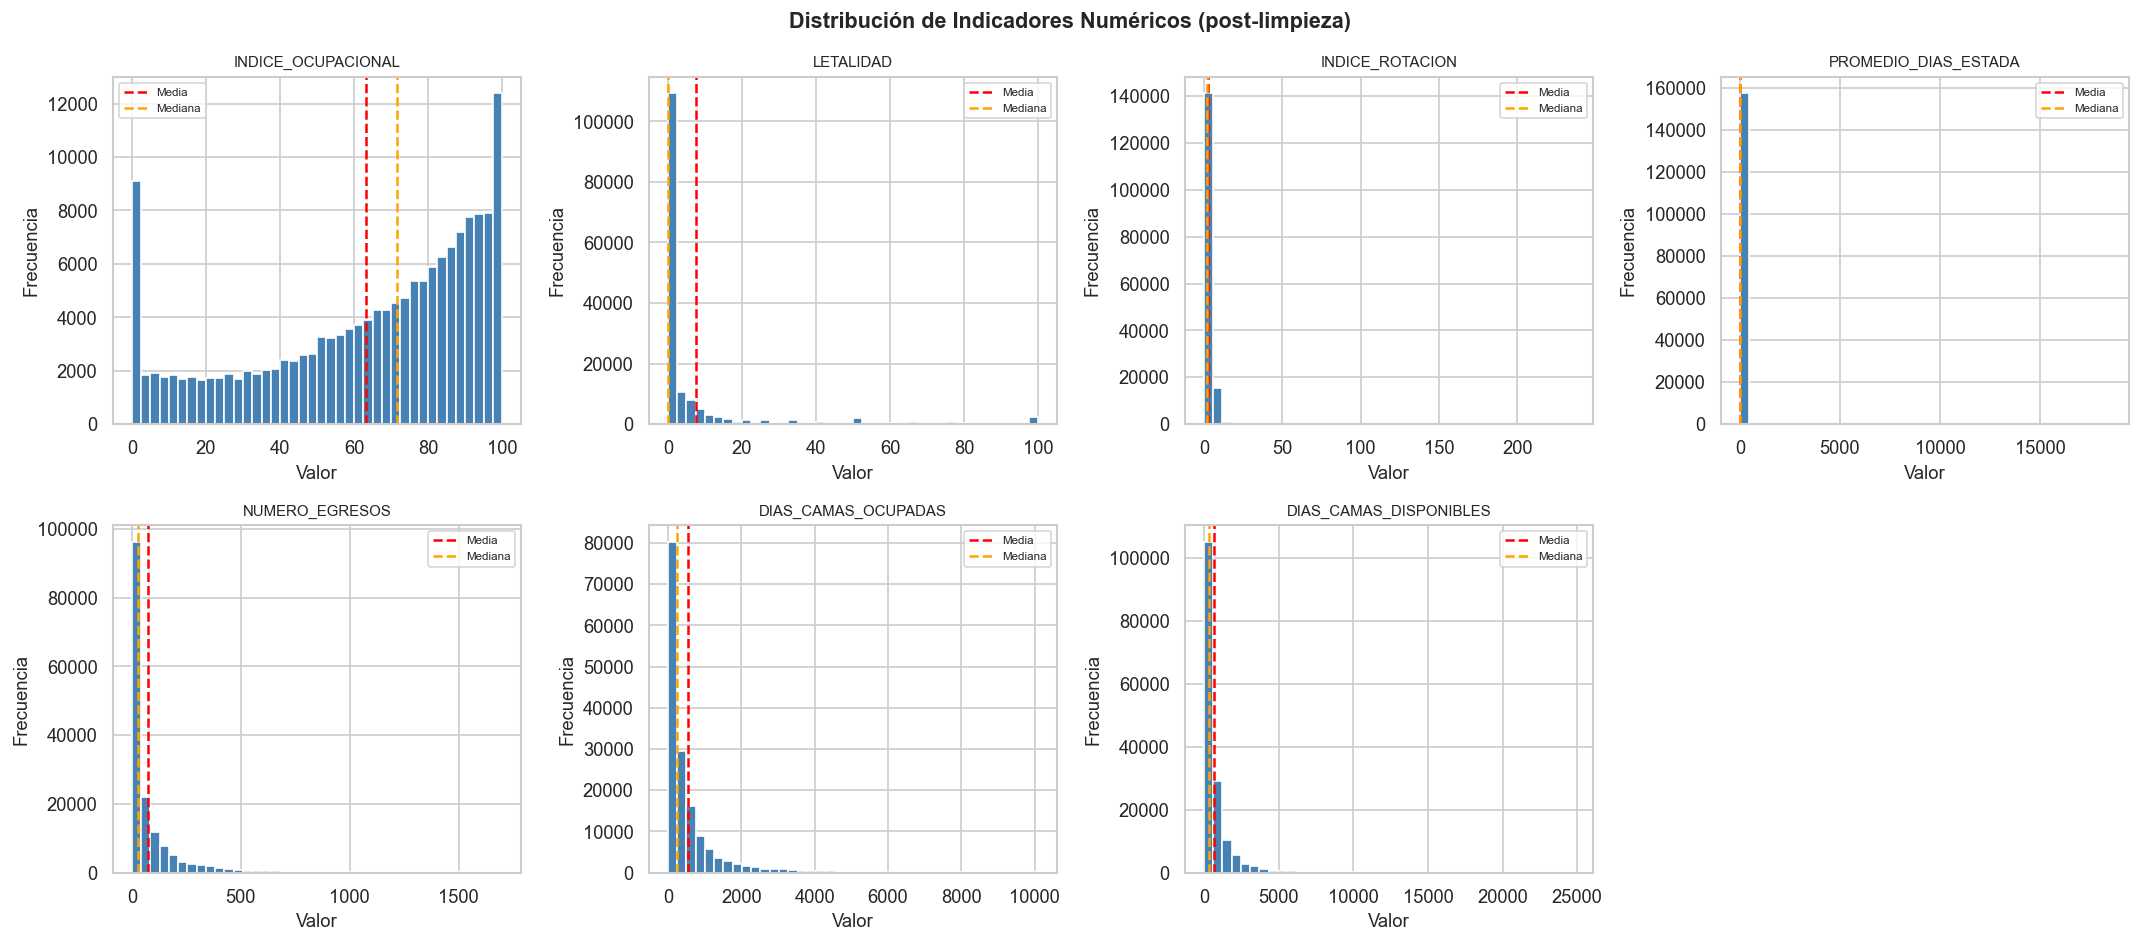

In [10]:
# Histogramas de los 7 indicadores principales
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribución de Indicadores Numéricos (post-limpieza)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col_name in enumerate(indicadores):
    col = df[col_name]
    axes[i].hist(col, bins=40, color='steelblue', edgecolor='white')
    axes[i].axvline(col.mean(),   color='red',    linestyle='--', linewidth=1.5, label='Media')
    axes[i].axvline(col.median(), color='orange', linestyle='--', linewidth=1.5, label='Mediana')
    axes[i].set_title(col_name, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

# Apagar el subplot sobrante
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## Pregunta 1
### ¿Cómo han evolucionado los patrones de hospitalización en los últimos años?

**Variables:** `NUMERO_EGRESOS`, `DIAS_CAMAS_OCUPADAS`, `DIAS_CAMAS_DISPONIBLES`, `INDICE_OCUPACIONAL` + `PERIODO` (eje temporal obligatorio)

In [11]:
# Agregación anual: sumar valores absolutos y promediar índice
p1 = df.groupby('PERIODO').agg(
    NUMERO_EGRESOS=('NUMERO_EGRESOS', 'sum'),
    DIAS_CAMAS_OCUPADAS=('DIAS_CAMAS_OCUPADAS', 'sum'),
    DIAS_CAMAS_DISPONIBLES=('DIAS_CAMAS_DISPONIBLES', 'sum'),
    INDICE_OCUPACIONAL=('INDICE_OCUPACIONAL', 'mean')
).reset_index()

print(p1.to_string(index=False))

 PERIODO  NUMERO_EGRESOS  DIAS_CAMAS_OCUPADAS  DIAS_CAMAS_DISPONIBLES  INDICE_OCUPACIONAL
    2014         1067047              6998626                 9011317           62.629082
    2015         1051574              7055535                 9054802           63.068878
    2016         1009229              7007367                 9044456           62.699612
    2017         1017924              7147256                 9132223           62.742811
    2018         1049542              7396873                 9301376           65.159187
    2019         1043294              7409376                 9294489           65.206827
    2020          835282              6442765                 9481987           54.735591
    2021          860227              7118585                 9435647           59.335756
    2022          920548              7247208                 9267495           63.481662
    2023          984377              7540145                 9357869           66.418170
    2024  

Visualización de la evolución temporal mediante gráficos de línea y barras para los cuatro indicadores principales.

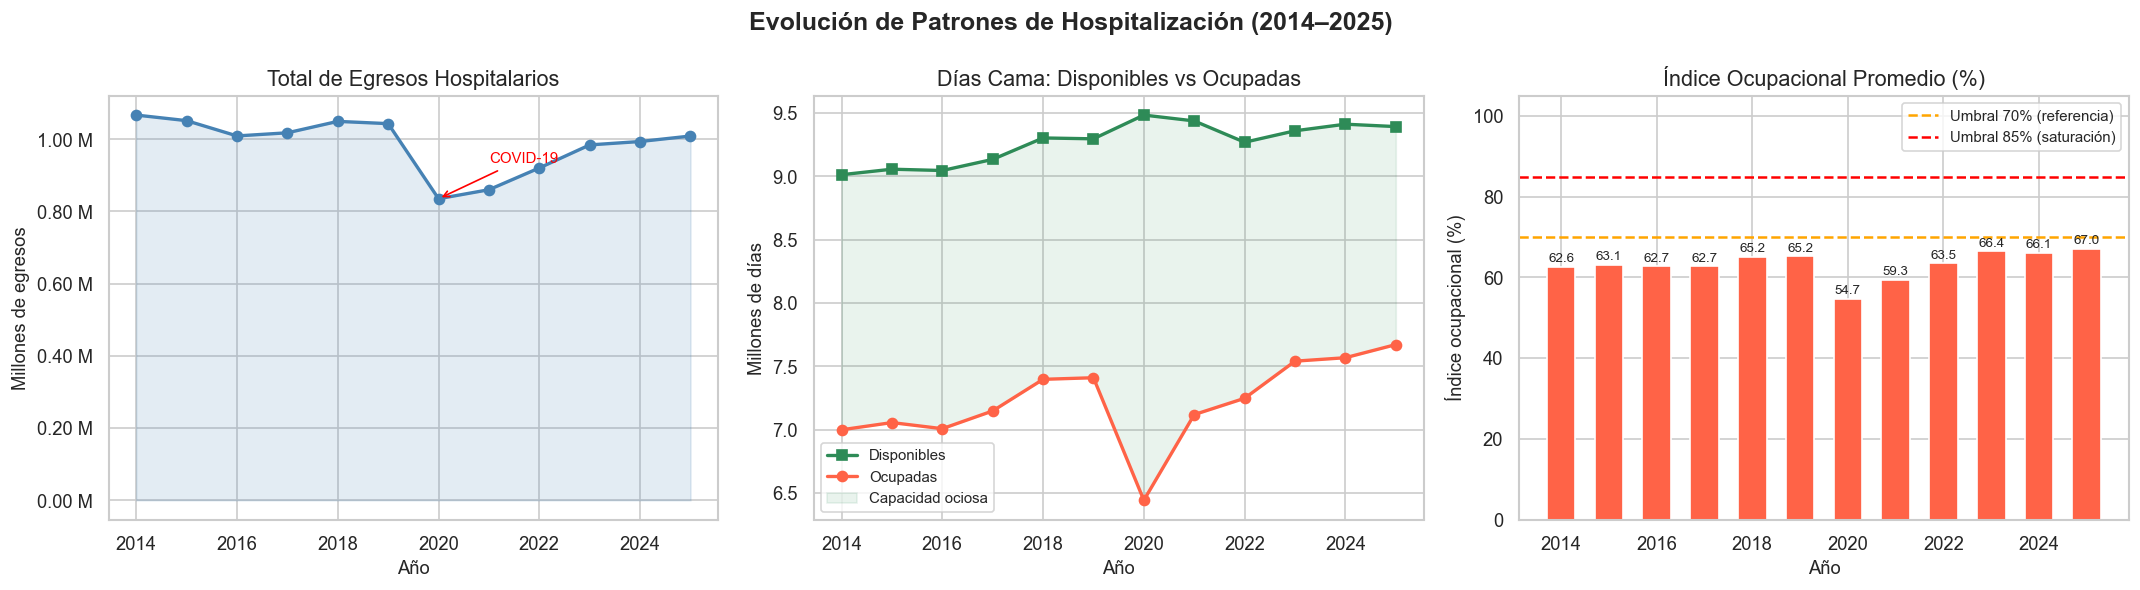

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evolución de Patrones de Hospitalización (2014–2025)', fontsize=15, fontweight='bold')

years = p1['PERIODO']

# --- Egresos totales ---
ax = axes[0]
ax.plot(years, p1['NUMERO_EGRESOS'] / 1e6, marker='o', linewidth=2, color='steelblue')
ax.fill_between(years, p1['NUMERO_EGRESOS'] / 1e6, alpha=0.15, color='steelblue')
ax.set_title('Total de Egresos Hospitalarios')
ax.set_ylabel('Millones de egresos')
ax.set_xlabel('Año')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f M'))

# Anotación caída COVID
if 2020 in p1['PERIODO'].values:
    val_2020 = p1.loc[p1['PERIODO'] == 2020, 'NUMERO_EGRESOS'].values[0] / 1e6
    ax.annotate('COVID-19', xy=(2020, val_2020),
                xytext=(2021, val_2020 + 0.1),
                arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)

# --- Días cama ocupadas vs disponibles ---
ax = axes[1]
ax.plot(years, p1['DIAS_CAMAS_DISPONIBLES'] / 1e6, marker='s', linewidth=2, label='Disponibles', color='seagreen')
ax.plot(years, p1['DIAS_CAMAS_OCUPADAS'] / 1e6, marker='o', linewidth=2, label='Ocupadas', color='tomato')
ax.fill_between(years,
                p1['DIAS_CAMAS_OCUPADAS'] / 1e6,
                p1['DIAS_CAMAS_DISPONIBLES'] / 1e6,
                alpha=0.1, color='seagreen', label='Capacidad ociosa')
ax.set_title('Días Cama: Disponibles vs Ocupadas')
ax.set_ylabel('Millones de días')
ax.set_xlabel('Año')
ax.legend(fontsize=9)

# --- Índice ocupacional promedio ---
ax = axes[2]
colors_bar = ['tomato' if v < 70 else 'steelblue' for v in p1['INDICE_OCUPACIONAL']]
bars = ax.bar(years, p1['INDICE_OCUPACIONAL'], color=colors_bar, edgecolor='white', width=0.6)
ax.axhline(70, color='orange', linestyle='--', linewidth=1.5, label='Umbral 70% (referencia)')
ax.axhline(85, color='red', linestyle='--', linewidth=1.5, label='Umbral 85% (saturación)')
ax.set_title('Índice Ocupacional Promedio (%)')
ax.set_ylabel('Índice ocupacional (%)')
ax.set_xlabel('Año')
ax.legend(fontsize=9)
ax.set_ylim(0, 105)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5, f'{h:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Cálculo de la variación porcentual entre el primer y último año del período para cuantificar los cambios observados.

In [13]:
# Variación porcentual 2014 → último año disponible
ultimo = p1.iloc[-1]
primero = p1.iloc[0]

for col in ['NUMERO_EGRESOS', 'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES', 'INDICE_OCUPACIONAL']:
    var = ((ultimo[col] - primero[col]) / primero[col]) * 100
    print(f"{col}: {primero[col]:,.1f} → {ultimo[col]:,.1f}  ({var:+.1f}%)")

# Año con menor índice ocupacional
min_occ = p1.loc[p1['INDICE_OCUPACIONAL'].idxmin()]
print(f"\nAño con menor índice ocupacional: {int(min_occ['PERIODO'])} ({min_occ['INDICE_OCUPACIONAL']:.1f}%)")

NUMERO_EGRESOS: 1,067,047.0 → 1,008,977.0  (-5.4%)
DIAS_CAMAS_OCUPADAS: 6,998,626.0 → 7,670,815.0  (+9.6%)
DIAS_CAMAS_DISPONIBLES: 9,011,317.0 → 9,391,017.0  (+4.2%)
INDICE_OCUPACIONAL: 62.6 → 67.0  (+7.0%)

Año con menor índice ocupacional: 2020 (54.7%)


### Conclusiones — Pregunta 1

El análisis temporal de los patrones de hospitalización entre 2014 y 2025 revela cuatro hallazgos principales:

- **Estabilidad estructural hasta 2019**: los egresos se mantuvieron sobre el millón anual y el índice ocupacional osciló entre 62 y 67%, sin cambios bruscos que indiquen transformaciones en el sistema.
- **Ruptura COVID-19 (2020)**: los egresos cayeron un 19% (de 1,04M a 0,84M), la mayor caída de toda la serie. Esto se explica por la suspensión de cirugías electivas y la reconfiguración del sistema hacia pacientes COVID-19.
- **Recuperación incompleta post-pandemia**: desde 2021 hay recuperación progresiva, pero los niveles de egresos de 2025 no recuperaron completamente los de 2014–2019, lo que indica que la pandemia dejó un efecto persistente.
- **Índice ocupacional promedio bajo el 70% todo el período**: esto podría sugerir subutilización, pero el promedio nacional oculta que la alta complejidad opera crónicamente entre 74–80% (ver Pregunta 4).

> **Respuesta a la pregunta**: los patrones de hospitalización se mantuvieron estructuralmente estables durante 2014–2025. La única excepción fue la pandemia de 2020, que constituye un quiebre extraordinario y transitorio del que el sistema se está recuperando progresivamente.


## Pregunta 2
### ¿Existen cambios temporales en la complejidad clínica de las hospitalizaciones?

**Variables:** `PROMEDIO_DIAS_ESTADA`, `LETALIDAD`, `INDICE_ROTACION`, `AREA_FUNCIONAL` + `PERIODO` (agregado para el eje temporal)

In [14]:
# Agregación anual de indicadores de complejidad clínica
p2_anual = df.groupby('PERIODO').agg(
    PROMEDIO_DIAS_ESTADA=('PROMEDIO_DIAS_ESTADA', 'mean'),
    LETALIDAD=('LETALIDAD', 'mean'),
    INDICE_ROTACION=('INDICE_ROTACION', 'mean')
).reset_index()

# Las áreas de alta complejidad son UCI adulto, UCI pediátrico e intermedios
AREAS_ALTA_COMPLEJIDAD = [
    'Área Cuidados Intensivos Adultos',
    'Área Cuidados Intensivos Pediátricos',
    'Área Cuidados Intermedios Adultos',
    'Área Cuidados Intermedios Pediátricos',
    'Área Neonatología Cuidados Intensivos'
]
AREAS_BAJA_COMPLEJIDAD = [
    'Área Médica Adulto Cuidados Básicos',
    'Área Médico-Quirúrgico Cuidados Básicos',
    'Área Obstetricia'
]

# Comparación por tipo de complejidad en el tiempo
df['COMPLEJIDAD'] = np.where(
    df['AREA_FUNCIONAL'].isin(AREAS_ALTA_COMPLEJIDAD), 'Alta complejidad',
    np.where(df['AREA_FUNCIONAL'].isin(AREAS_BAJA_COMPLEJIDAD), 'Baja complejidad', 'Media complejidad')
)

p2_comp = df.groupby(['PERIODO', 'COMPLEJIDAD']).agg(
    PROMEDIO_DIAS_ESTADA=('PROMEDIO_DIAS_ESTADA', 'mean'),
    LETALIDAD=('LETALIDAD', 'mean'),
    INDICE_ROTACION=('INDICE_ROTACION', 'mean')
).reset_index()

print(p2_anual.round(2).to_string(index=False))

 PERIODO  PROMEDIO_DIAS_ESTADA  LETALIDAD  INDICE_ROTACION
    2014                 16.49       7.52             3.28
    2015                 17.81       7.54             3.26
    2016                 17.16       7.69             2.95
    2017                 17.29       7.82             2.91
    2018                 18.90       7.76             3.02
    2019                 20.33       7.85             2.97
    2020                 18.36       8.00             2.25
    2021                 19.87       7.89             2.41
    2022                 19.54       7.76             2.63
    2023                 19.46       7.59             2.78
    2024                 19.43       7.53             2.70
    2025                 21.12       7.47             2.78


Visualización de la evolución temporal de los tres indicadores de complejidad clínica, segmentados por nivel.

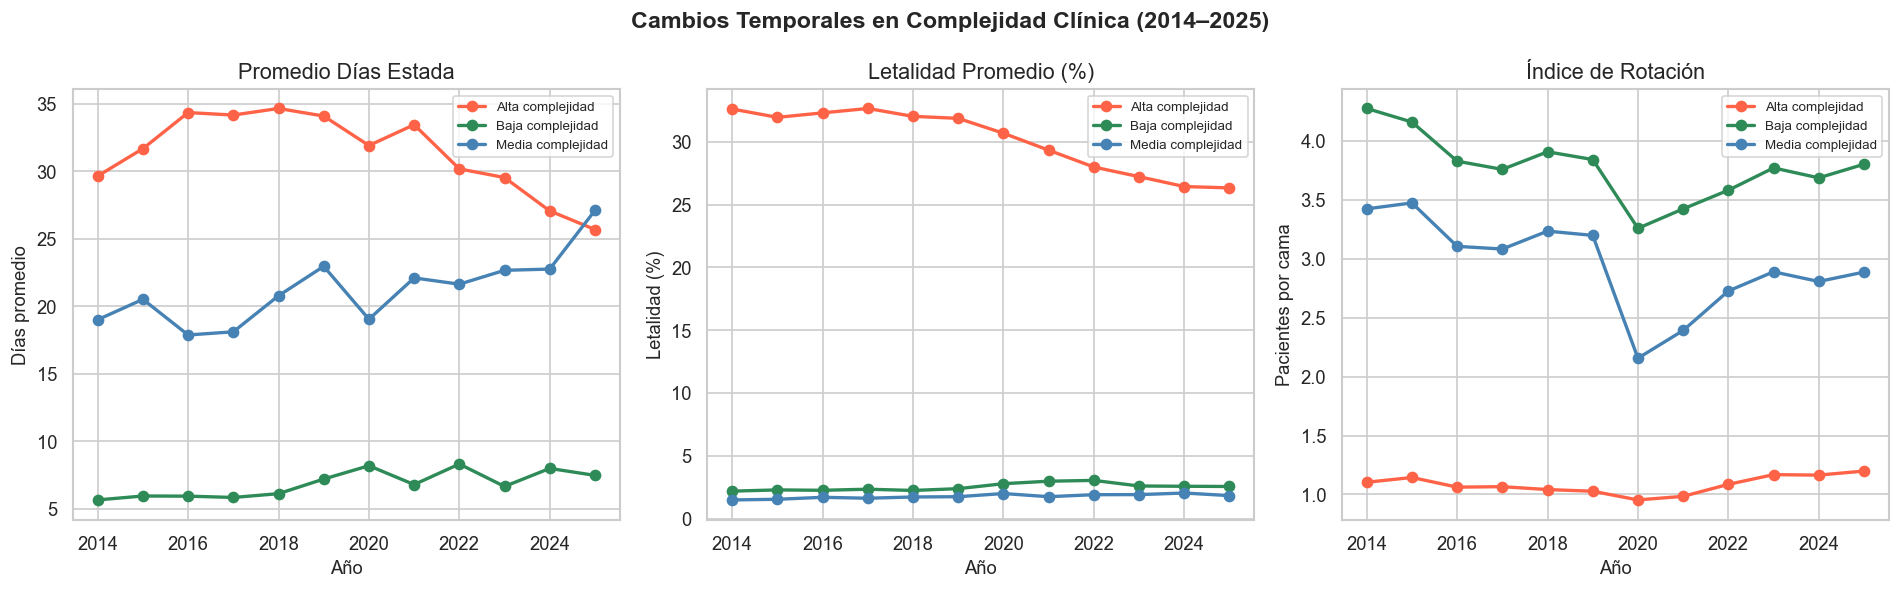

In [15]:
# Este gráfico tiene 3 paneles, uno por cada indicador de complejidad clínica.
# En cada panel hay 3 líneas de colores distintos: roja (alta complejidad),
# verde (baja complejidad) y azul (media complejidad).
# El eje X es el año y el eje Y es el valor promedio del indicador ese año.
# La separación entre líneas muestra las diferencias estructurales entre grupos,
# y la tendencia de cada línea muestra si el indicador subió, bajó o se mantuvo.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cambios Temporales en Complejidad Clínica (2014–2025)', fontsize=14, fontweight='bold')


for comp, grp in p2_comp.groupby('COMPLEJIDAD'):
    grp = grp.sort_values('PERIODO')
    axes[0].plot(grp['PERIODO'], grp['PROMEDIO_DIAS_ESTADA'], marker='o', label=comp,
                 color=palette[comp], linewidth=2)
    axes[1].plot(grp['PERIODO'], grp['LETALIDAD'], marker='o', label=comp,
                 color=palette[comp], linewidth=2)
    axes[2].plot(grp['PERIODO'], grp['INDICE_ROTACION'], marker='o', label=comp,
                 color=palette[comp], linewidth=2)

axes[0].set_title('Promedio Días Estada')
axes[0].set_ylabel('Días promedio')
axes[0].set_xlabel('Año')
axes[0].legend(fontsize=8)

axes[1].set_title('Letalidad Promedio (%)')
axes[1].set_ylabel('Letalidad (%)')
axes[1].set_xlabel('Año')
axes[1].legend(fontsize=8)

axes[2].set_title('Índice de Rotación')
axes[2].set_ylabel('Pacientes por cama')
axes[2].set_xlabel('Año')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

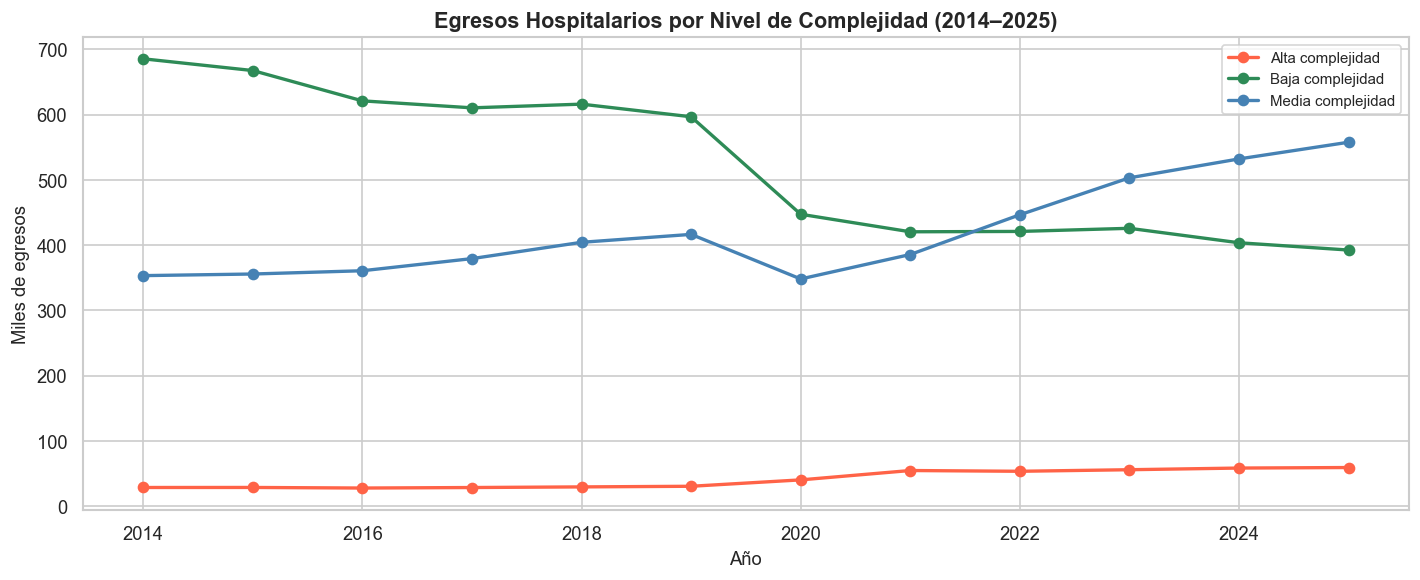

In [16]:
# Egresos totales por año y nivel de complejidad
egresos_complejidad = df.groupby(['PERIODO', 'COMPLEJIDAD'])['NUMERO_EGRESOS'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

for comp, grp in egresos_complejidad.groupby('COMPLEJIDAD'):
    grp = grp.sort_values('PERIODO')
    ax.plot(grp['PERIODO'], grp['NUMERO_EGRESOS'] / 1e3,
            marker='o', linewidth=2, label=comp, color=palette[comp])

ax.set_title('Egresos Hospitalarios por Nivel de Complejidad (2014–2025)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Miles de egresos')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Identificación de las áreas funcionales con mayor letalidad histórica promedio.

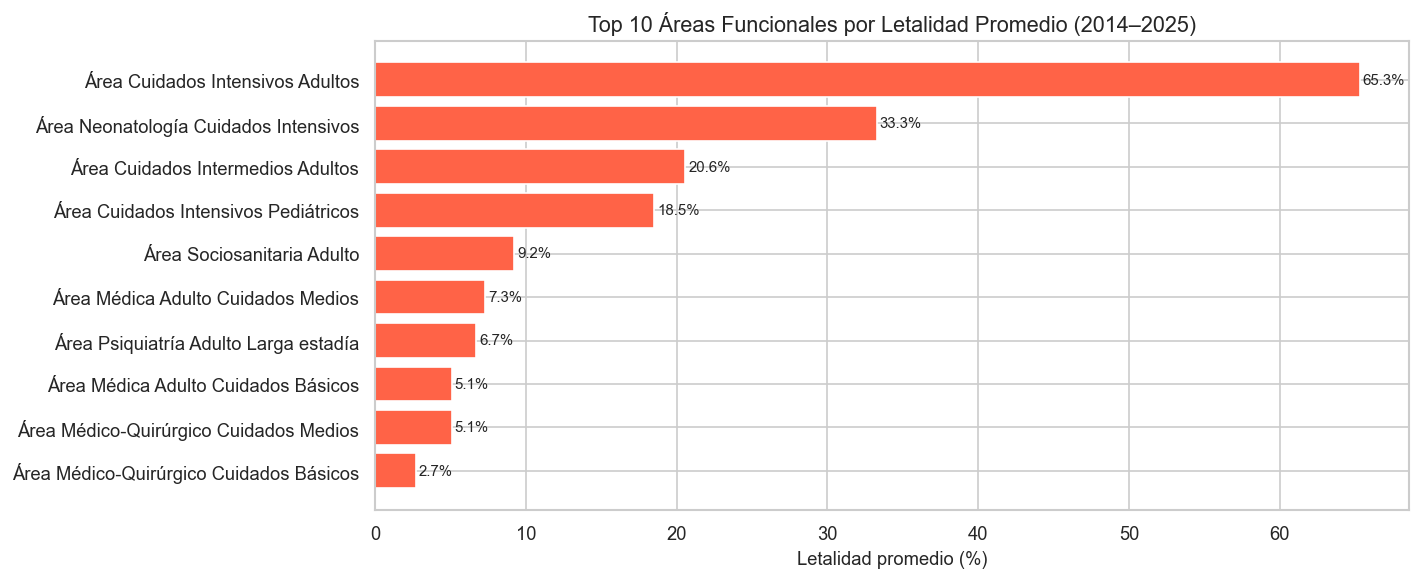

In [17]:
# Top 10 áreas funcionales con mayor letalidad promedio histórica
top_letalidad = (
    df.groupby('AREA_FUNCIONAL')['LETALIDAD']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_letalidad['AREA_FUNCIONAL'], top_letalidad['LETALIDAD'],
               color='tomato', edgecolor='white')
ax.set_xlabel('Letalidad promedio (%)')
ax.set_title('Top 10 Áreas Funcionales por Letalidad Promedio (2014–2025)')
ax.invert_yaxis()
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.2, bar.get_y() + bar.get_height() / 2, f'{w:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Conclusiones — Pregunta 2

El análisis temporal de complejidad clínica revela cambios estructurales relevantes en el período:

- **Desplazamiento hacia mayor complejidad**: los egresos de baja complejidad cayeron de ~680.000 (2014) a ~400.000 (2025), mientras los de alta complejidad aumentaron de ~25.000 a ~60.000. El sistema está atendiendo progresivamente más casos graves.
- **Baja en letalidad de alta complejidad explicada por volumen**: el porcentaje de letalidad en UCI bajó en los últimos años, pero no porque los casos sean menos graves, sino porque hay más pacientes atendidos en total. El número absoluto de muertes puede haberse mantenido o aumentado.
- **Media complejidad supera a alta en días de estadía (2025)**: la estadía promedio de alta complejidad bajó sostenidamente, siendo superada por media complejidad en 2025, lo que refleja el desplazamiento del perfil de casos.
- **Baja complejidad estable**: sus indicadores se mantuvieron sin cambios relevantes durante todo el período, incluyendo 2020 donde continuó atendiéndose con normalidad.

> **Respuesta a la pregunta**: sí existen cambios temporales en la complejidad clínica. El sistema se está desplazando progresivamente hacia más casos de alta y media complejidad y menos de baja complejidad.


## Pregunta 3
### ¿Cómo varía la duración promedio de la hospitalización entre áreas funcionales y en el tiempo?

**Variables:** `PROMEDIO_DIAS_ESTADA`, `AREA_FUNCIONAL`, `PERIODO`

In [18]:
# Promedio de días estada por área funcional y año
p3 = df.groupby(['AREA_FUNCIONAL', 'PERIODO'])['PROMEDIO_DIAS_ESTADA'].mean().reset_index()

# Tabla pivot para heatmap
p3_pivot = p3.pivot(index='AREA_FUNCIONAL', columns='PERIODO', values='PROMEDIO_DIAS_ESTADA')
p3_pivot = p3_pivot.sort_values(by=p3_pivot.columns[-1], ascending=False)

print("Áreas con mayor promedio de días de estada (último año):")
print(p3_pivot.iloc[:, -1].sort_values(ascending=False).head(10).round(1))

Áreas con mayor promedio de días de estada (último año):
AREA_FUNCIONAL
Área Psiquiatría Adulto Larga estadía                                   879.2
Área Psiquiatría Forense Adulto tratamiento                             726.3
Área Psiquiatría Forense Adulto evaluación e inicio tto.                256.6
Área Psiquiatría Adulto Mediana estadía                                 194.3
Área Sociosanitaria Adulto                                              108.4
Área Psiquiatría Infanto-adolescente mediana estadía                     69.5
Área Neonatología Cuidados Intensivos                                    46.8
Área Cuidados Intensivos Pediátricos                                     32.9
Área Psiquiatría Forense Infanto Adolescente tratamiento                 32.0
Área de Hospitalización de Cuidados Intensivos en Psiquiatría Adulto     29.0
Name: 2025, dtype: float64


Heatmap de días de estada por área funcional y año para identificar patrones espaciales y temporales.

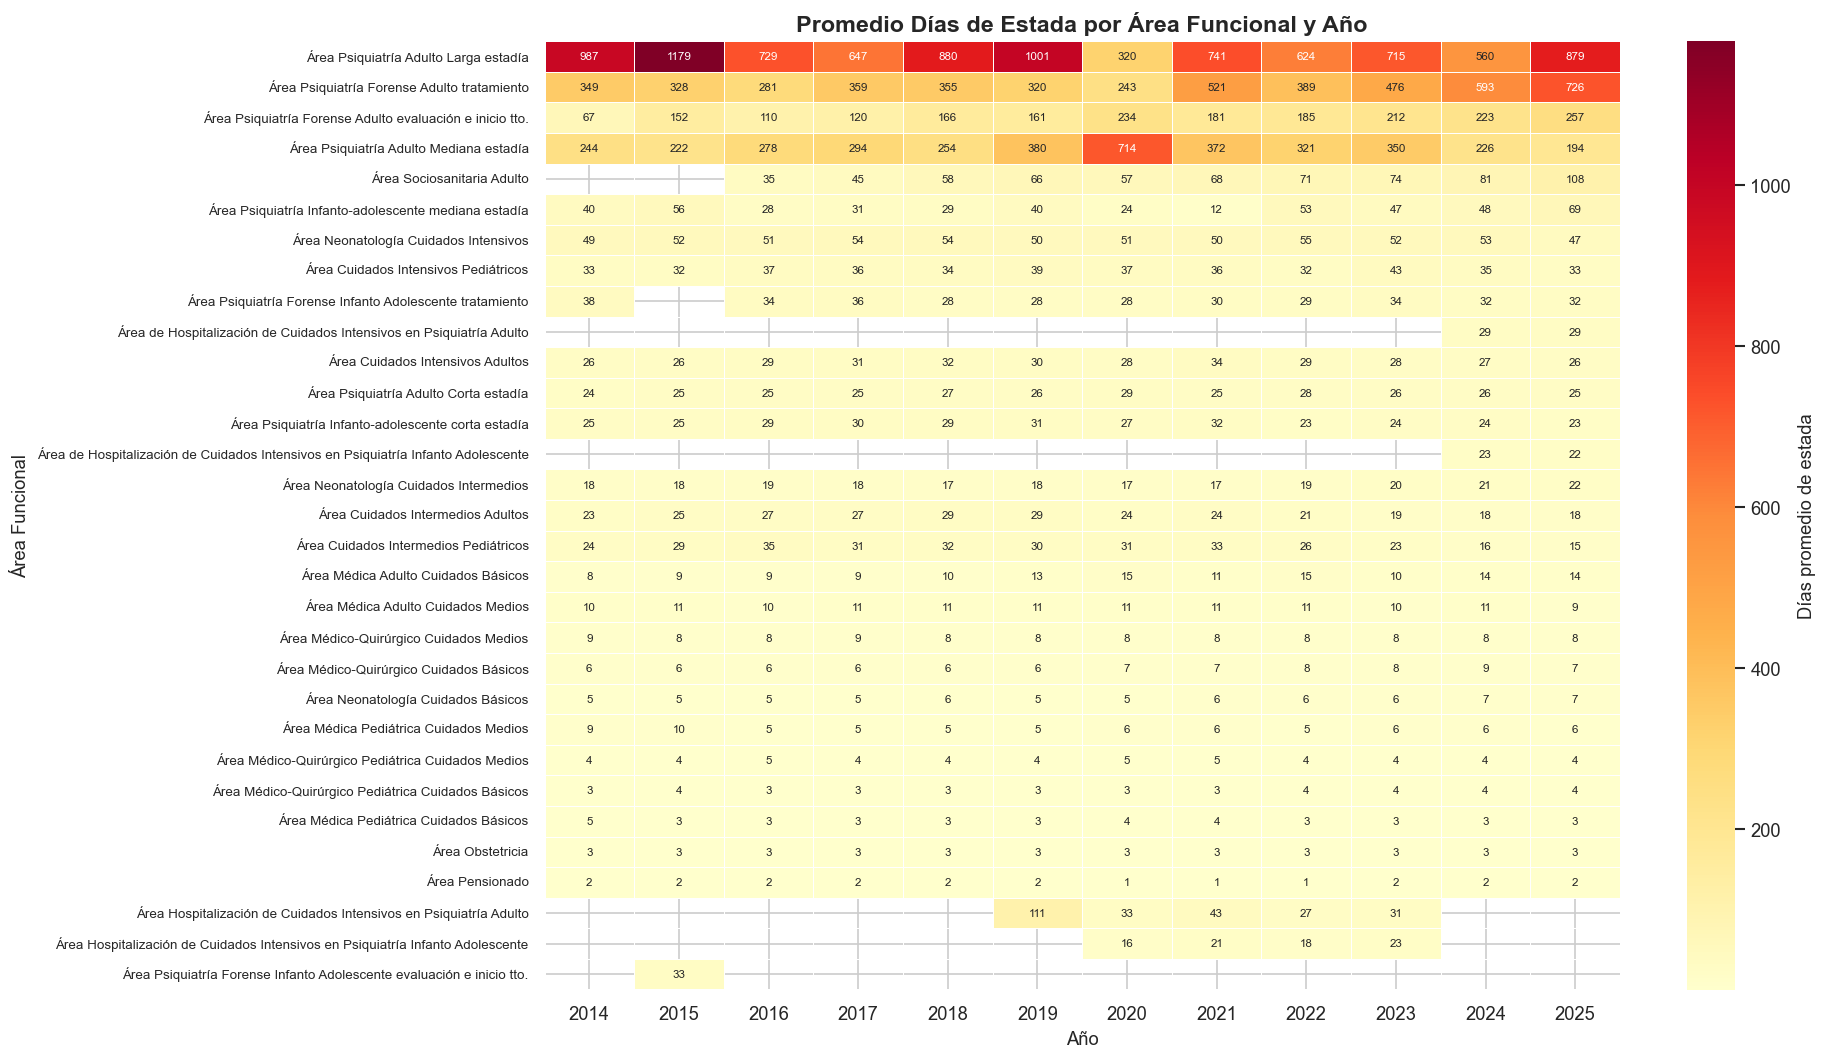

In [19]:
# Heatmap: días estada por área funcional y año
fig, ax = plt.subplots(figsize=(16, 9))

# Heatmap de días estada por área funcional y año
sns.heatmap(
    p3_pivot,
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Días promedio de estada'},
    ax=ax
)
ax.set_title('Promedio Días de Estada por Área Funcional y Año', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Área Funcional')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

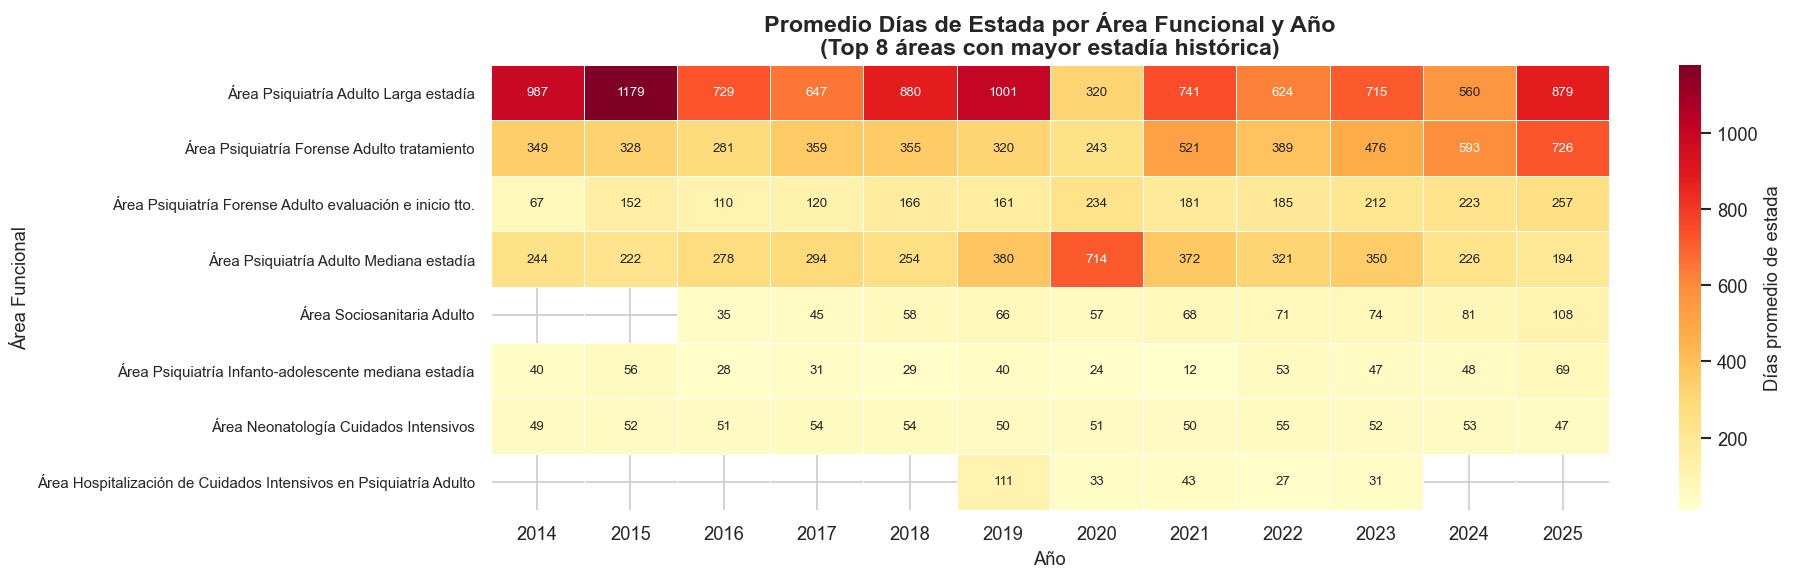

In [20]:
# Seleccionar solo las 8 áreas con mayor promedio histórico de días de estada
top8_areas = (
    df.groupby('AREA_FUNCIONAL')['PROMEDIO_DIAS_ESTADA']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

# Filtrar el pivot solo con esas 8 áreas
p3_pivot_top8 = p3_pivot.loc[p3_pivot.index.isin(top8_areas)]
p3_pivot_top8 = p3_pivot_top8.sort_values(by=p3_pivot_top8.columns[-1], ascending=False)

# Heatmap con top 8
fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(
    p3_pivot_top8,
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Días promedio de estada'},
    ax=ax
)
ax.set_title('Promedio Días de Estada por Área Funcional y Año\n(Top 8 áreas con mayor estadía histórica)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Área Funcional')
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

Evolución temporal de las 8 áreas con mayor promedio de estadía histórica.

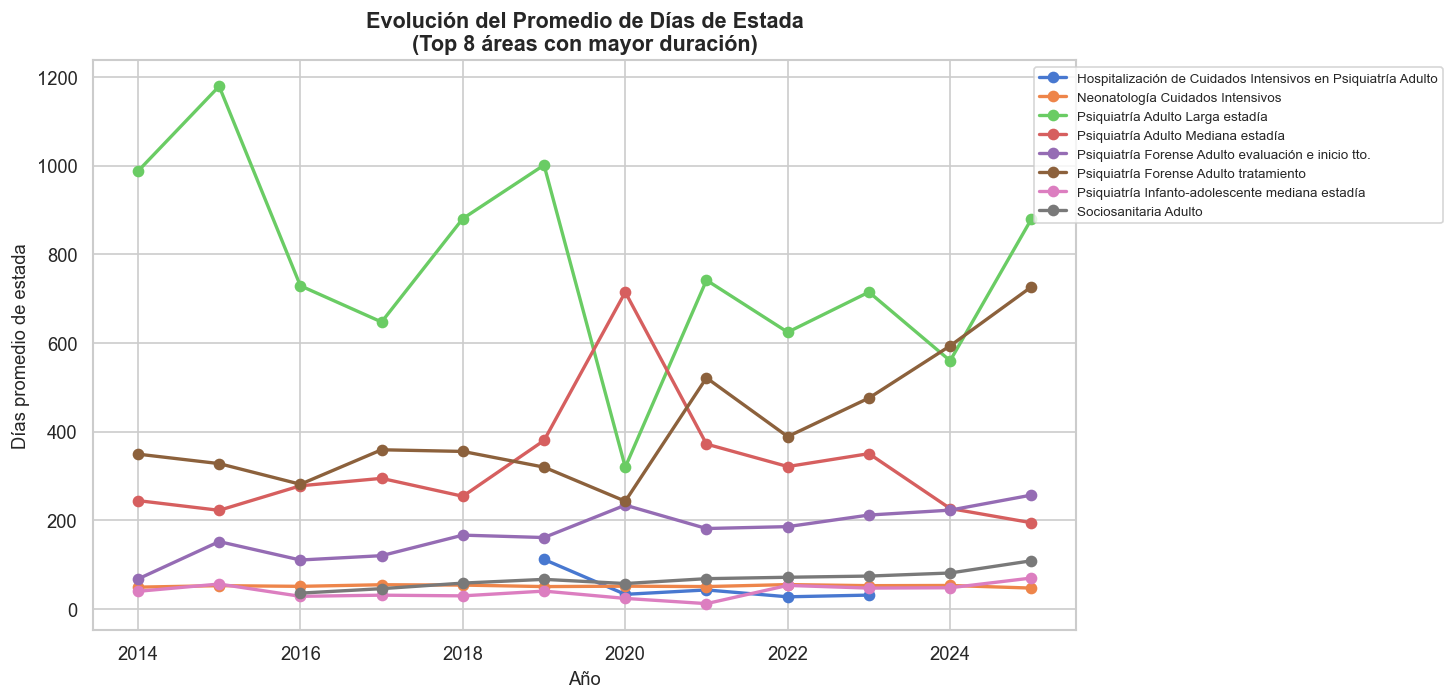

In [21]:
# Evolución temporal para las 8 áreas con mayor promedio de días estada
top8_areas = (
    df.groupby('AREA_FUNCIONAL')['PROMEDIO_DIAS_ESTADA']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

p3_top = p3[p3['AREA_FUNCIONAL'].isin(top8_areas)]

fig, ax = plt.subplots(figsize=(13, 6))
for area, grp in p3_top.groupby('AREA_FUNCIONAL'):
    grp = grp.sort_values('PERIODO')
    # Nombre corto para la leyenda
    label = area.replace('Área ', '').strip()
    ax.plot(grp['PERIODO'], grp['PROMEDIO_DIAS_ESTADA'], marker='o', linewidth=2, label=label)

ax.set_title('Evolución del Promedio de Días de Estada\n(Top 8 áreas con mayor duración)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Días promedio de estada')
ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.38, 1))
plt.tight_layout()
plt.show()

Distribución de los días de estada por área funcional mediante boxplots, ordenados por mediana.

C:\Users\bravo\AppData\Local\Temp\ipykernel_31460\278923970.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


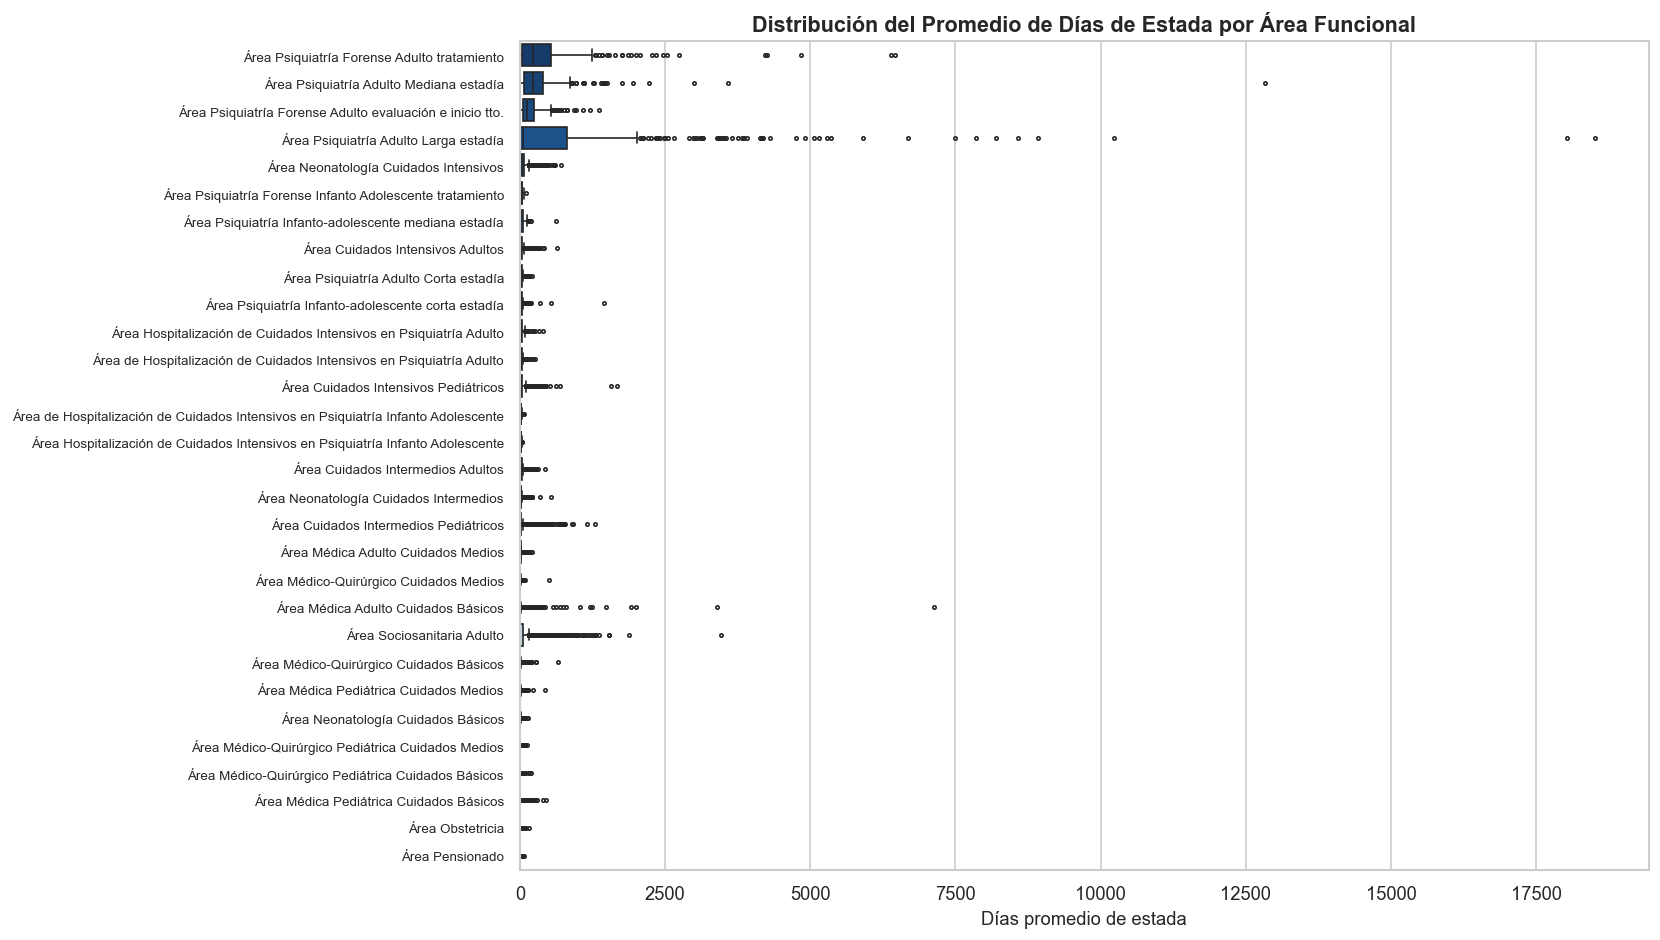

In [22]:
# Distribución general de días estada por área funcional (boxplot)
# Filtrar áreas con al menos 100 registros para que sea representativo
areas_validas = df['AREA_FUNCIONAL'].value_counts()[lambda x: x >= 100].index
df_box = df[df['AREA_FUNCIONAL'].isin(areas_validas)]

# Calcular mediana por área para ordenar
orden = (
    df_box.groupby('AREA_FUNCIONAL')['PROMEDIO_DIAS_ESTADA']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(
    data=df_box,
    x='PROMEDIO_DIAS_ESTADA',
    y='AREA_FUNCIONAL',
    order=orden,
    palette='Blues_r',
    fliersize=2,
    ax=ax
)
ax.set_title('Distribución del Promedio de Días de Estada por Área Funcional', fontweight='bold')
ax.set_xlabel('Días promedio de estada')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

C:\Users\bravo\AppData\Local\Temp\ipykernel_31460\885997051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


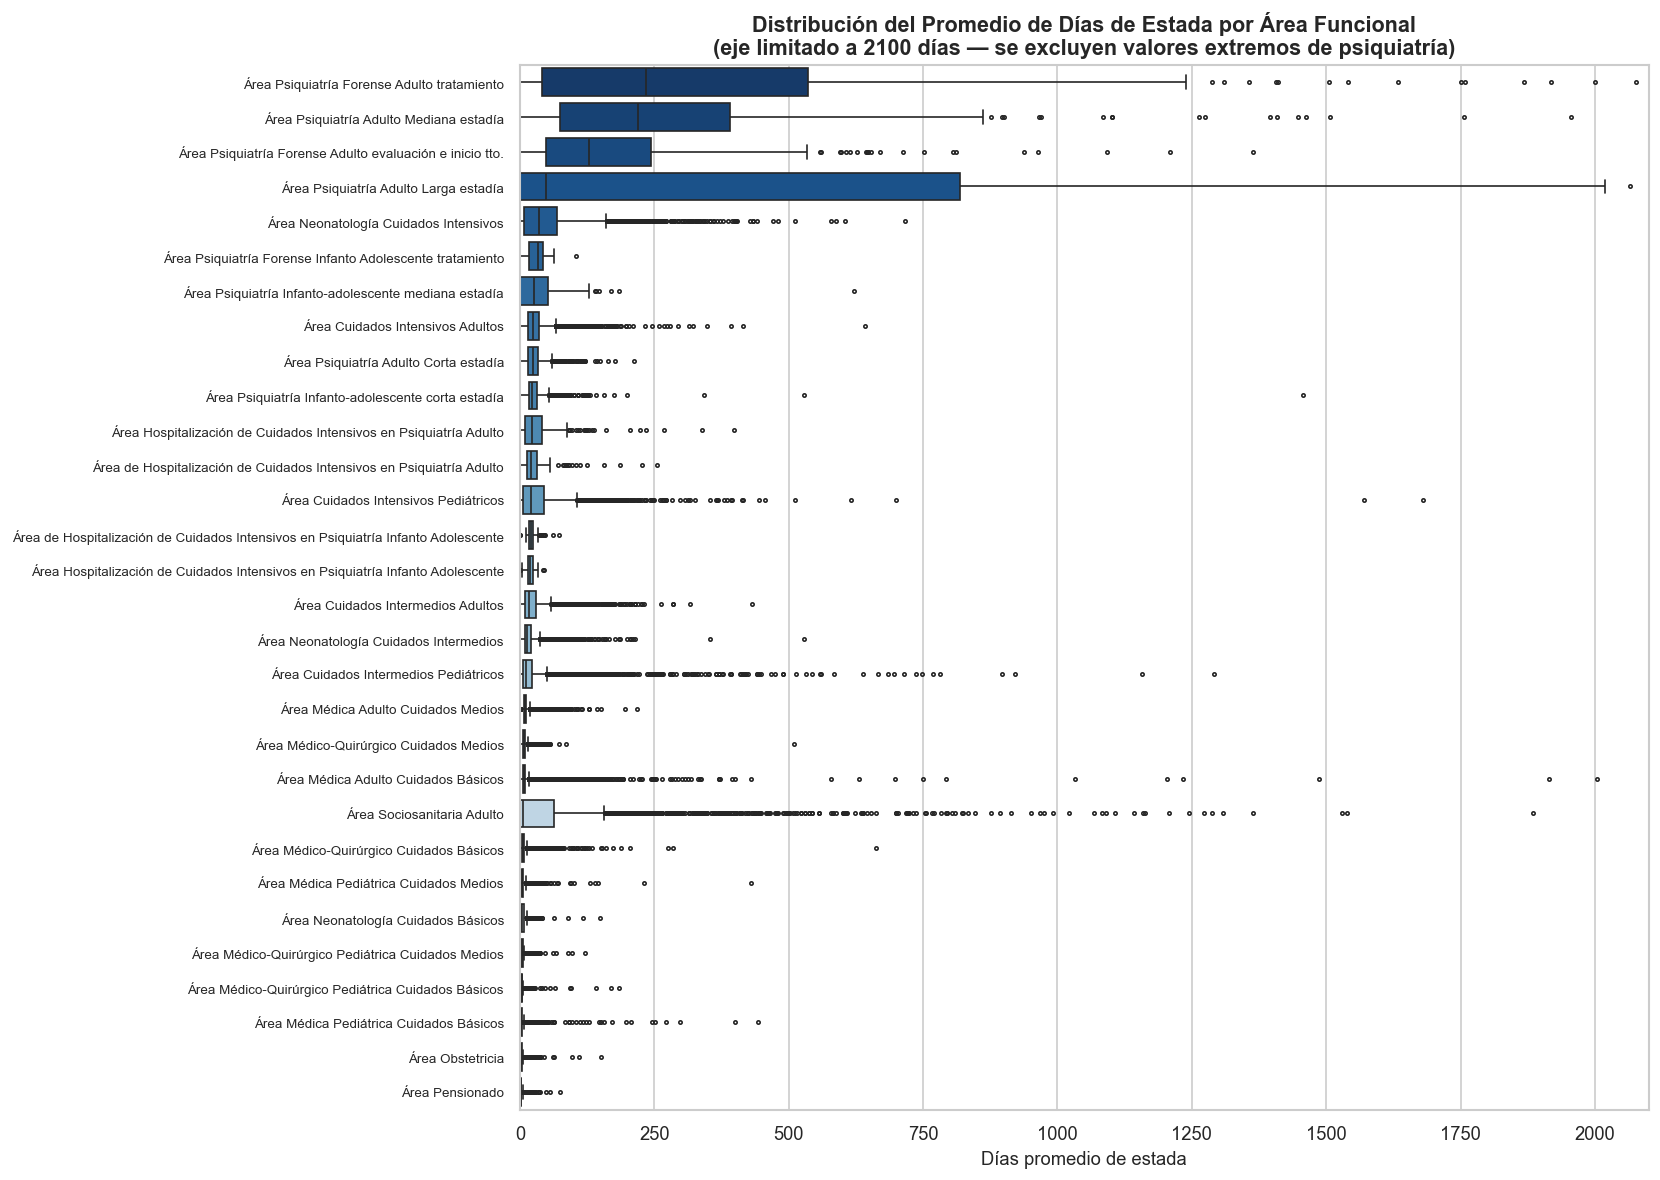

In [23]:
# Boxplot con eje limitado para mejor visualización (excluye valores extremos de psiquiatría)
fig, ax = plt.subplots(figsize=(14, 10))
sns.boxplot(
    data=df_box,
    x='PROMEDIO_DIAS_ESTADA',
    y='AREA_FUNCIONAL',
    order=orden,
    palette='Blues_r',
    fliersize=2,
    ax=ax
)
ax.set_title('Distribución del Promedio de Días de Estada por Área Funcional\n(eje limitado a 2100 días — se excluyen valores extremos de psiquiatría)', fontweight='bold')
ax.set_xlabel('Días promedio de estada')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlim(0, 2100)  # ← limita el eje, los puntos fuera quedan cortados
plt.tight_layout()
plt.savefig('p3_boxplot_limitado.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones — Pregunta 3

El análisis de la duración promedio de hospitalización por área funcional muestra diferencias estructurales marcadas y algunas tendencias relevantes en el tiempo:

- **Psiquiatría lidera ampliamente**: con estadías de cientos a miles de días, muy por encima del resto de áreas. Esta diferencia es estructural y se mantiene durante todo el período.
- **Alta complejidad muestra tendencia a la baja**: los días de estadía en UCI y cuidados intensivos bajaron en los últimos años, siendo superados por media complejidad en 2025. Esto es coherente con el aumento del volumen de pacientes atendidos en estas unidades.
- **Media complejidad aumentó su estadía**: tendencia al alza desde 2020, consistente con el desplazamiento del perfil de casos identificado en la Pregunta 2.
- **Baja complejidad estable**: estadías cortas entre 3 y 15 días sin cambios relevantes en el período.
- **Efecto pandemia diferenciado**: en 2020 la mayoría de áreas bajó su estadía, excepto Psiquiatría Adulto Mediana Estadía que subió a 714 días. Post pandemia los valores se estabilizaron sin recuperar los niveles de 2014–2015.

> **Respuesta a la pregunta**: la duración varía enormemente entre áreas (3 días en obstetricia vs ~1.000 días en psiquiatría de larga estadía). Estas diferencias son estructurales, pero sí hay cambios: alta complejidad bajó su estadía en los últimos años mientras media complejidad la aumentó.


## Pregunta 4
### ¿Cómo ha variado la eficiencia en el uso de camas hospitalarias a lo largo del tiempo?

**Variables:** `PERIODO`, `INDICE_OCUPACIONAL`, `INDICE_ROTACION` + `AREA_FUNCIONAL` (para comparar UCI vs otras)

In [24]:
# Agregación anual general
p4_anual = df.groupby('PERIODO').agg(
    INDICE_OCUPACIONAL=('INDICE_OCUPACIONAL', 'mean'),
    INDICE_ROTACION=('INDICE_ROTACION', 'mean')
).reset_index()

# Por área funcional y año (usar grupos de complejidad ya definidos)
p4_comp = df.groupby(['PERIODO', 'COMPLEJIDAD']).agg(
    INDICE_OCUPACIONAL=('INDICE_OCUPACIONAL', 'mean'),
    INDICE_ROTACION=('INDICE_ROTACION', 'mean')
).reset_index()

print("Variación anual de índices de eficiencia:")
print(p4_anual.round(2).to_string(index=False))

Variación anual de índices de eficiencia:
 PERIODO  INDICE_OCUPACIONAL  INDICE_ROTACION
    2014               62.63             3.28
    2015               63.07             3.26
    2016               62.70             2.95
    2017               62.74             2.91
    2018               65.16             3.02
    2019               65.21             2.97
    2020               54.74             2.25
    2021               59.34             2.41
    2022               63.48             2.63
    2023               66.42             2.78
    2024               66.07             2.70
    2025               67.01             2.78


Visualización comparativa del índice ocupacional e índice de rotación, tanto a nivel general como por nivel de complejidad.

Heatmap del índice ocupacional por área funcional y año (top 15 áreas por volumen de registros).

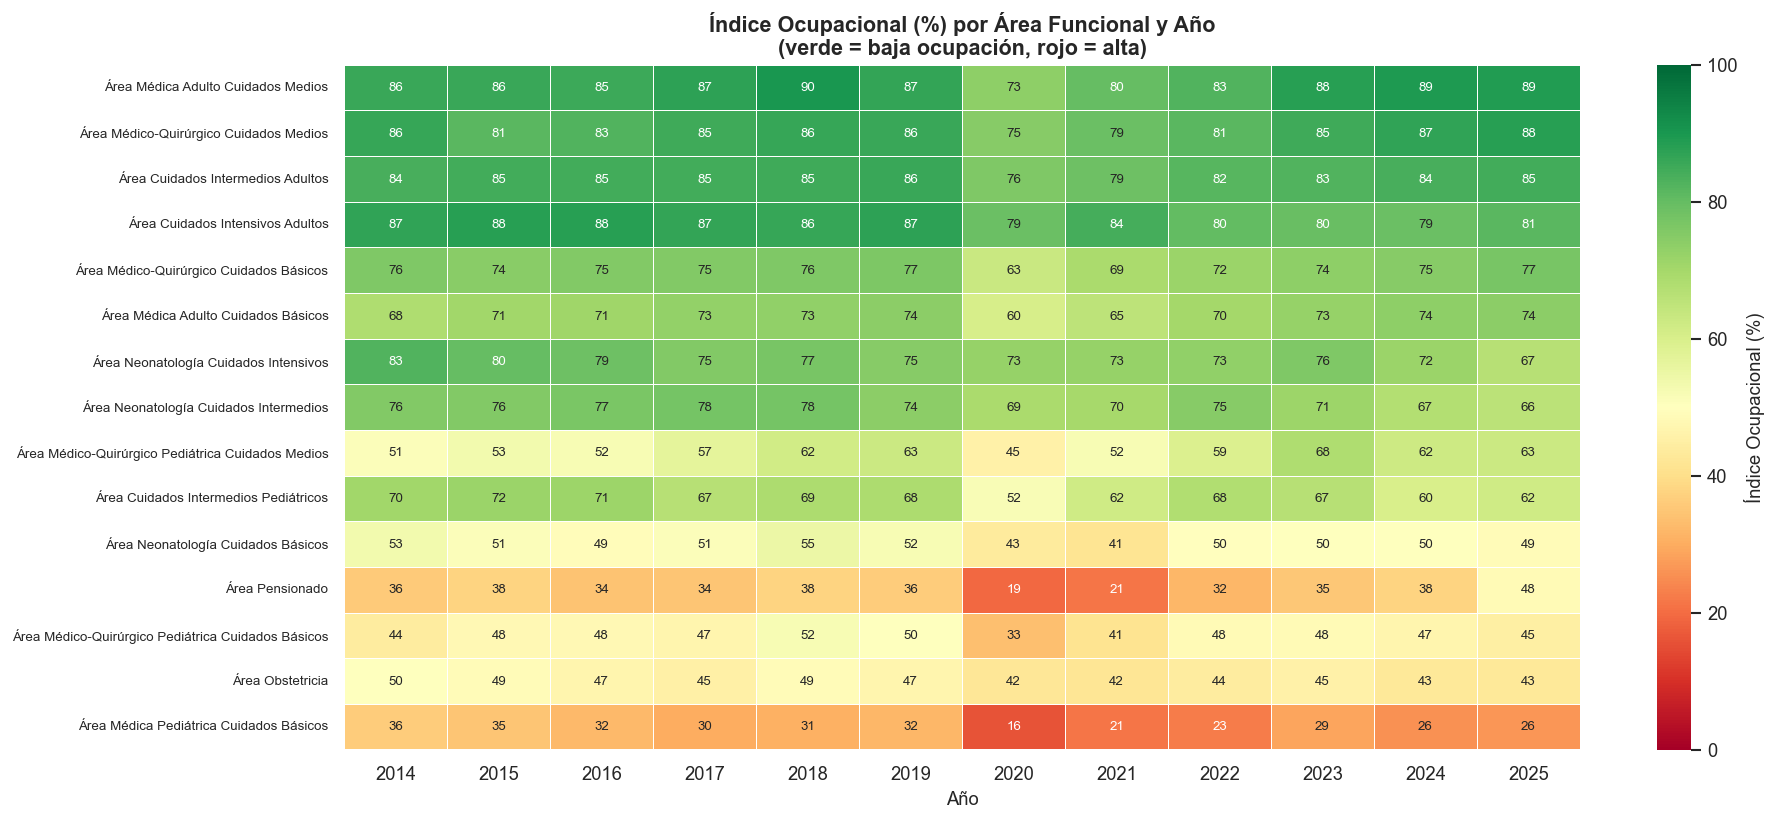

In [25]:
# Heatmap: índice ocupacional promedio por área funcional y año
# Filtrar para las áreas más relevantes (top 15 por número de registros)
top15_areas = df['AREA_FUNCIONAL'].value_counts().head(15).index.tolist()

p4_heat = (
    df[df['AREA_FUNCIONAL'].isin(top15_areas)]
    .groupby(['AREA_FUNCIONAL', 'PERIODO'])['INDICE_OCUPACIONAL']
    .mean()
    .reset_index()
    .pivot(index='AREA_FUNCIONAL', columns='PERIODO', values='INDICE_OCUPACIONAL')
)
p4_heat = p4_heat.sort_values(by=p4_heat.columns[-1], ascending=False)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    p4_heat,
    cmap='RdYlGn',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f',
    annot_kws={'size': 8},
    vmin=0, vmax=100,
    cbar_kws={'label': 'Índice Ocupacional (%)'},
    ax=ax
)
ax.set_title('Índice Ocupacional (%) por Área Funcional y Año\n(verde = baja ocupación, rojo = alta)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

### Conclusiones — Pregunta 4

El análisis de eficiencia en el uso de camas revela que el problema no es global sino heterogéneo:

- **Alta complejidad crónicamente saturada**: opera entre 74–80% de ocupación durante casi todo el período, consistentemente sobre el umbral del 70% recomendado por la OMS. En algunos años estuvo cerca del 85%, nivel a partir del cual la literatura reporta riesgo de colapso operacional (NICE, 2018).
- **Media y baja complejidad subutilizadas**: operan significativamente por debajo del 70%, lo que arrastra el promedio nacional hacia abajo y genera una imagen falsa de holgura en el sistema.
- **Impacto COVID-19 uniforme**: en 2020 todos los niveles de complejidad cayeron simultáneamente, pero la alta complejidad cayó menos porque las UCIs nunca dejaron de funcionar.
- **Recuperación asimétrica post-pandemia**: hacia 2025 la alta complejidad volvió a sus niveles habituales de saturación, mientras media y baja no recuperaron completamente los niveles previos.

> **Respuesta a la pregunta**: la eficiencia en el uso de camas no mejoró estructuralmente durante el período. El problema real no es que el sistema sea ineficiente en promedio, sino que la distribución es extremadamente heterogénea: UCIs saturadas coexisten con áreas subutilizadas en el mismo sistema.


## Pregunta 5
### ¿Existe relación entre la ocupación hospitalaria y la letalidad de los pacientes?

**Variables:** `INDICE_OCUPACIONAL` (explicativa), `LETALIDAD` (respuesta) + `AREA_FUNCIONAL` (segmentación) + `PERIODO` (evolución)

In [26]:
# Filtrar valores válidos (descartar ceros que pueden ser registros sin actividad)
df_p5 = df[(df['INDICE_OCUPACIONAL'] > 0) & (df['LETALIDAD'] >= 0)].copy()

r_pearson, p_pearson = pearsonr(df_p5['INDICE_OCUPACIONAL'], df_p5['LETALIDAD'])
r_spearman, p_spearman = spearmanr(df_p5['INDICE_OCUPACIONAL'], df_p5['LETALIDAD'])

print(f"Correlación de Pearson:  r = {r_pearson:.4f}  (p-value = {p_pearson:.4e})")
print(f"Correlación de Spearman: r = {r_spearman:.4f}  (p-value = {p_spearman:.4e})")
print()

# Correlación por complejidad
print("Correlación de Pearson por nivel de complejidad:")
for comp in df_p5['COMPLEJIDAD'].unique():
    sub = df_p5[df_p5['COMPLEJIDAD'] == comp]
    r, p = pearsonr(sub['INDICE_OCUPACIONAL'], sub['LETALIDAD'])
    print(f"  {comp}: r = {r:.4f}  (p = {p:.4e}, n = {len(sub):,})")

Correlación de Pearson:  r = 0.2256  (p-value = 0.0000e+00)
Correlación de Spearman: r = 0.3941  (p-value = 0.0000e+00)

Correlación de Pearson por nivel de complejidad:
  Alta complejidad: r = 0.2511  (p = 0.0000e+00, n = 31,671)
  Baja complejidad: r = 0.1971  (p = 0.0000e+00, n = 46,751)
  Media complejidad: r = 0.1717  (p = 0.0000e+00, n = 71,925)


Visualización de la dispersión entre índice ocupacional y letalidad, a nivel global y segmentado por complejidad.

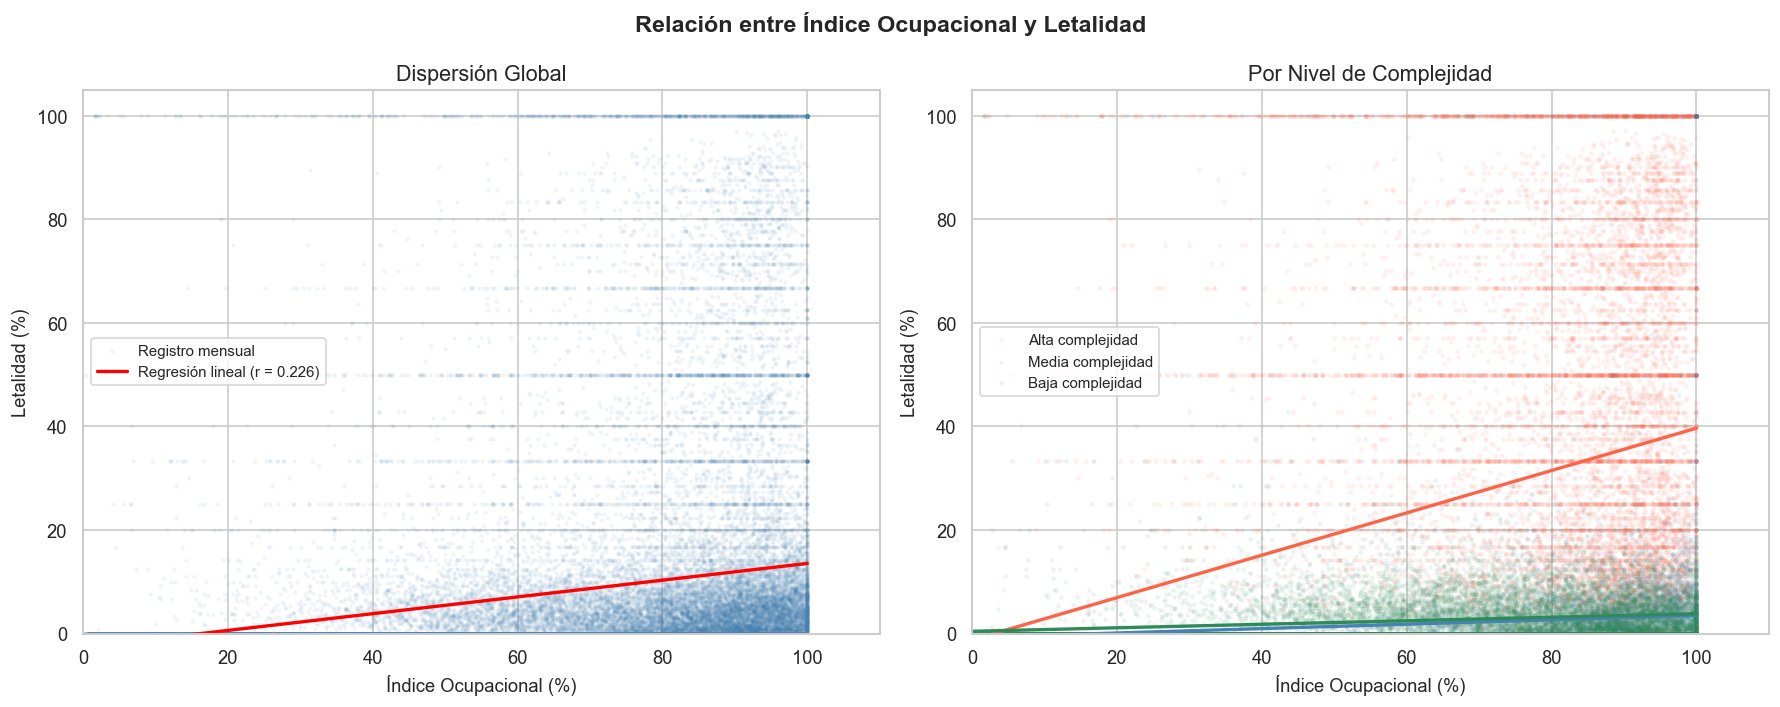

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Relación entre Índice Ocupacional y Letalidad', fontsize=14, fontweight='bold')

# --- Scatter general con regresión ---
ax = axes[0]
# Muestra aleatoria para no saturar el gráfico (100k puntos)
sample = df_p5.sample(min(50000, len(df_p5)), random_state=42)
ax.scatter(sample['INDICE_OCUPACIONAL'], sample['LETALIDAD'],
           alpha=0.05, s=3, color='steelblue', label='Registro mensual')

# Línea de regresión
m, b = np.polyfit(df_p5['INDICE_OCUPACIONAL'], df_p5['LETALIDAD'], 1)
x_line = np.linspace(df_p5['INDICE_OCUPACIONAL'].min(), df_p5['INDICE_OCUPACIONAL'].max(), 200)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2,
        label=f'Regresión lineal (r = {r_pearson:.3f})')

ax.set_xlabel('Índice Ocupacional (%)')
ax.set_ylabel('Letalidad (%)')
ax.set_title('Dispersión Global')
ax.legend(fontsize=9)
ax.set_xlim(0, 110)
ax.set_ylim(0, 105)

# --- Scatter por nivel de complejidad ---
ax = axes[1]
for comp in ['Alta complejidad', 'Media complejidad', 'Baja complejidad']:
    sub = df_p5[df_p5['COMPLEJIDAD'] == comp].sample(min(15000, len(df_p5[df_p5['COMPLEJIDAD'] == comp])), random_state=42)
    ax.scatter(sub['INDICE_OCUPACIONAL'], sub['LETALIDAD'],
               alpha=0.06, s=4, color=palette[comp], label=comp)
    # Tendencia por grupo
    m2, b2 = np.polyfit(df_p5[df_p5['COMPLEJIDAD'] == comp]['INDICE_OCUPACIONAL'],
                         df_p5[df_p5['COMPLEJIDAD'] == comp]['LETALIDAD'], 1)
    ax.plot(x_line, m2 * x_line + b2, color=palette[comp], linewidth=2)

ax.set_xlabel('Índice Ocupacional (%)')
ax.set_ylabel('Letalidad (%)')
ax.set_title('Por Nivel de Complejidad')
ax.legend(fontsize=9)
ax.set_xlim(0, 110)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

Análisis de la letalidad promedio según rangos de ocupación, para identificar umbrales de saturación.

   Rango Ocupación  Letalidad Media  Letalidad Mediana  N registros
      0-50% (Baja)             2.11               0.00        39403
 50-70% (Moderada)             5.59               0.00        29289
     70-85% (Alta)             9.23               0.00        32062
85-100% (Muy alta)            13.60               2.63        49593


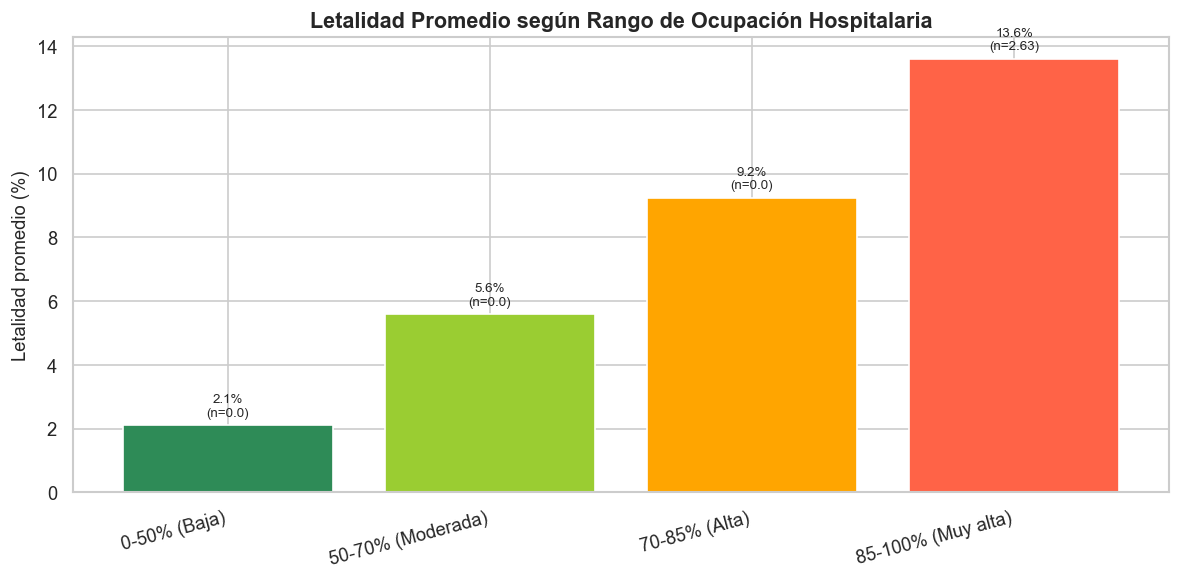

In [28]:
# Análisis por rangos de ocupación: ¿sube la letalidad con alta saturación?
df_p5['RANGO_OCUPACION'] = pd.cut(
    df_p5['INDICE_OCUPACIONAL'],
    bins=[0, 50, 70, 85, 100],
    labels=['0-50% (Baja)', '50-70% (Moderada)', '70-85% (Alta)', '85-100% (Muy alta)']
)

p5_bins = df_p5.groupby('RANGO_OCUPACION', observed=True)['LETALIDAD'].agg(['mean', 'median', 'count']).reset_index()
p5_bins.columns = ['Rango Ocupación', 'Letalidad Media', 'Letalidad Mediana', 'N registros']
print(p5_bins.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(p5_bins))
bars = ax.bar(x, p5_bins['Letalidad Media'],
              color=['seagreen', 'yellowgreen', 'orange', 'tomato'],
              edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(p5_bins['Rango Ocupación'], rotation=15, ha='right')
ax.set_ylabel('Letalidad promedio (%)')
ax.set_title('Letalidad Promedio según Rango de Ocupación Hospitalaria', fontweight='bold')
for bar, row in zip(bars, p5_bins.itertuples()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.2,
            f'{h:.1f}%\n(n={row._3:,})', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

Evolución temporal paralela del índice ocupacional y la letalidad promedio anual.

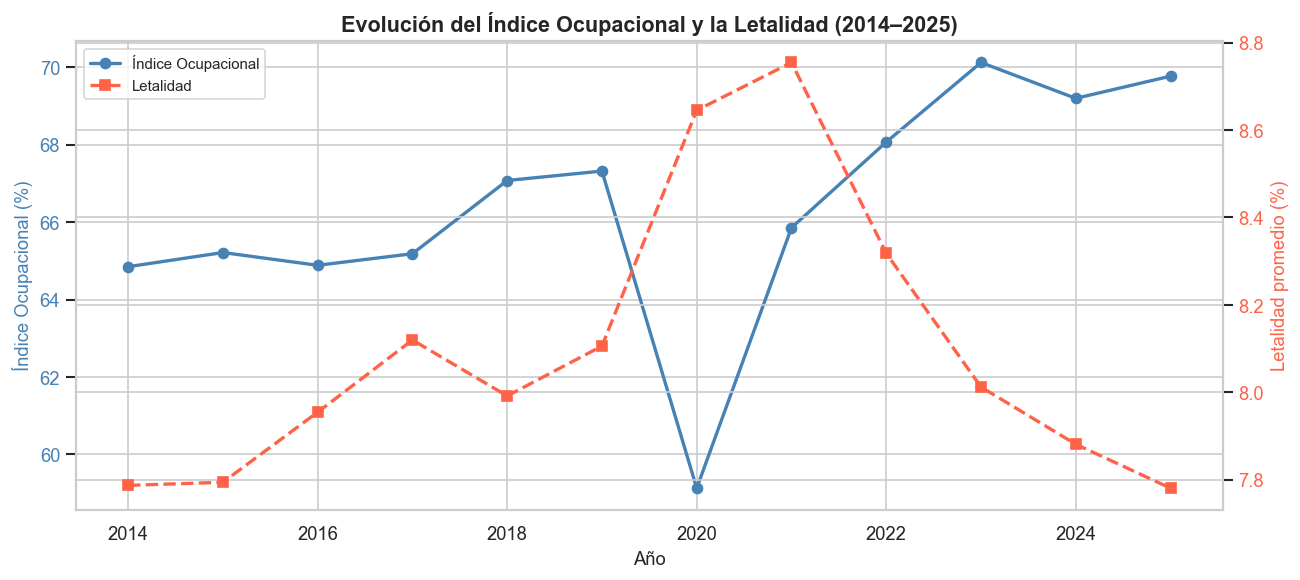

In [29]:
# Evolución temporal de la relación ocupación-letalidad
p5_anual = df_p5.groupby('PERIODO').agg(
    INDICE_OCUPACIONAL=('INDICE_OCUPACIONAL', 'mean'),
    LETALIDAD=('LETALIDAD', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(p5_anual['PERIODO'], p5_anual['INDICE_OCUPACIONAL'],
         marker='o', color='steelblue', linewidth=2, label='Índice Ocupacional')
ax2.plot(p5_anual['PERIODO'], p5_anual['LETALIDAD'],
         marker='s', color='tomato', linewidth=2, linestyle='--', label='Letalidad')

ax1.set_xlabel('Año')
ax1.set_ylabel('Índice Ocupacional (%)', color='steelblue')
ax2.set_ylabel('Letalidad promedio (%)', color='tomato')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title('Evolución del Índice Ocupacional y la Letalidad (2014–2025)', fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusiones — Pregunta 5

El análisis de correlación entre índice ocupacional y letalidad revela una relación que depende fuertemente del nivel de complejidad analizado:

- **Correlación global débil pero significativa**: el coeficiente de Pearson es r = 0,226 (positivo), lo que indica una relación lineal débil a nivel nacional. No es una correlación fuerte, pero sí estadísticamente significativa dado el tamaño del dataset.
- **Alta complejidad tiene pendiente pronunciada**: al segmentar por nivel de complejidad, la alta complejidad muestra una relación clara entre mayor ocupación y mayor letalidad. En media y baja complejidad la relación es casi nula.
- **El análisis agregado enmascara la relación**: mezclar todas las áreas en un solo número (r = 0,226) oculta que la relación existe con fuerza en alta complejidad pero no en las demás. Esta es la razón por la que el análisis agregado es insuficiente.
- **Paradoja pandemia 2020**: la ocupación cayó drásticamente en 2020 pero la letalidad no bajó, porque los pacientes que sí se hospitalizaron eran en promedio más graves que en años previos.

> **Respuesta a la pregunta**: sí existe relación entre ocupación y letalidad, pero solo es relevante en alta complejidad. A mayor ocupación en UCI, mayor letalidad. A nivel nacional el promedio agrega unidades con perfiles tan distintos que la relación se diluye.


---

## 9. Estimación Estadística

Esta sección aplica los conceptos de **estimación puntual** e **intervalos de confianza** sobre los indicadores principales del dataset, y realiza **comparaciones entre grupos** clave.

> Los intervalos de confianza se calculan al **95%** usando la distribución t de Student (apropiada para muestras grandes con varianza desconocida).


### 9.1 Estimadores puntuales e intervalos de confianza al 95%

Para cada indicador cuantitativo se estima la media poblacional mediante su estimador puntual (media muestral) y se construye un intervalo de confianza al 95% usando la distribución t de Student.

In [30]:
from scipy import stats as scipy_stats

# Parámetros de interés: media de cada indicador con IC 95%
print("ESTIMADORES PUNTUALES E INTERVALOS DE CONFIANZA AL 95%")
print("="*65)

indicadores_ic = {
    'INDICE_OCUPACIONAL': 'Índice Ocupacional (%)',
    'LETALIDAD':          'Letalidad (%)',
    'PROMEDIO_DIAS_ESTADA': 'Promedio Días de Estada',
    'INDICE_ROTACION':    'Índice de Rotación',
    'NUMERO_EGRESOS':     'Número de Egresos',
}

resultados_ic = []
for col, label in indicadores_ic.items():
    serie = df[col].dropna()
    n      = len(serie)
    media  = serie.mean()
    std    = serie.std(ddof=1)
    ee     = std / (n ** 0.5)                         # error estándar
    t_crit = scipy_stats.t.ppf(0.975, df=n - 1)      # t crítico bilateral 95%
    margen = t_crit * ee
    ic_inf = media - margen
    ic_sup = media + margen

    resultados_ic.append({
        'Indicador':  label,
        'n':          n,
        'Media':      round(media, 3),
        'Desv. Std':  round(std, 3),
        'Error Std':  round(ee, 4),
        'IC 95% inf': round(ic_inf, 3),
        'IC 95% sup': round(ic_sup, 3),
    })
    print(f"\n{label}")
    print(f"  n = {n:,}  |  Media = {media:.3f}  |  IC 95% = [{ic_inf:.3f}, {ic_sup:.3f}]")

df_ic = pd.DataFrame(resultados_ic)
print("\n\nTabla resumen:")
display(df_ic)

ESTIMADORES PUNTUALES E INTERVALOS DE CONFIANZA AL 95%

Índice Ocupacional (%)
  n = 157,996  |  Media = 63.185  |  IC 95% = [63.035, 63.335]

Letalidad (%)
  n = 157,996  |  Media = 7.703  |  IC 95% = [7.608, 7.799]

Promedio Días de Estada
  n = 157,996  |  Media = 18.832  |  IC 95% = [18.182, 19.483]

Índice de Rotación
  n = 157,996  |  Media = 2.821  |  IC 95% = [2.806, 2.836]

Número de Egresos
  n = 157,996  |  Media = 74.950  |  IC 95% = [74.331, 75.569]


Tabla resumen:


,Indicador,n,Media,Desv. Std,Error Std,IC 95% inf,IC 95% sup
0,Índice Ocupacional (%),157996,63.185,30.361,0.0764,63.035,63.335
1,Letalidad (%),157996,7.703,19.288,0.0485,7.608,7.799
2,Promedio Días de Estada,157996,18.832,131.982,0.3320,18.182,19.483
3,Índice de Rotación,157996,2.821,3.108,0.0078,2.806,2.836
4,Número de Egresos,157996,74.950,125.470,0.3157,74.331,75.569


### 9.2 Comparación entre grupos: nivel de complejidad

Se comparan los indicadores principales entre áreas de alta, media y baja complejidad clínica.

In [31]:
# Tabla resumen comparativa por nivel de complejidad
grupos = ['Alta complejidad', 'Media complejidad', 'Baja complejidad']

cols_comp = ['INDICE_OCUPACIONAL', 'LETALIDAD', 'PROMEDIO_DIAS_ESTADA', 'INDICE_ROTACION']

print("COMPARACIÓN DE INDICADORES POR NIVEL DE COMPLEJIDAD")
print("="*65)

resumen_grupos = []
for g in grupos:
    sub = df[df['COMPLEJIDAD'] == g]
    fila = {'Grupo': g, 'n': len(sub)}
    for c in cols_comp:
        serie = sub[c].dropna()
        n     = len(serie)
        media = serie.mean()
        std   = serie.std(ddof=1)
        ee    = std / (n ** 0.5)
        t_c   = scipy_stats.t.ppf(0.975, df=n - 1)
        margen = t_c * ee
        fila[f'{c}_media'] = round(media, 2)
        fila[f'{c}_IC_inf'] = round(media - margen, 2)
        fila[f'{c}_IC_sup'] = round(media + margen, 2)
    resumen_grupos.append(fila)

df_grupos = pd.DataFrame(resumen_grupos)

# Mostrar tabla limpia por indicador
for c in cols_comp:
    print(f"\n{c}")
    print(f"  {'Grupo':<30} {'Media':>8}  {'IC 95% inf':>12}  {'IC 95% sup':>12}  {'n':>10}")
    print("  " + "-"*68)
    for g in grupos:
        row = df_grupos[df_grupos['Grupo'] == g].iloc[0]
        n_g = df[df['COMPLEJIDAD'] == g][c].count()
        print(f"  {g:<30} {row[f'{c}_media']:>8.2f}  {row[f'{c}_IC_inf']:>12.2f}  {row[f'{c}_IC_sup']:>12.2f}  {n_g:>10,}")

COMPARACIÓN DE INDICADORES POR NIVEL DE COMPLEJIDAD

INDICE_OCUPACIONAL
  Grupo                             Media    IC 95% inf    IC 95% sup           n
  --------------------------------------------------------------------
  Alta complejidad                  76.21         75.98         76.44      31,947
  Media complejidad                 58.32         58.09         58.56      77,500
  Baja complejidad                  62.37         62.12         62.63      48,549

LETALIDAD
  Grupo                             Media    IC 95% inf    IC 95% sup           n
  --------------------------------------------------------------------
  Alta complejidad                  29.94         29.58         30.30      31,947
  Media complejidad                  1.78          1.73          1.83      77,500
  Baja complejidad                   2.52          2.48          2.56      48,549

PROMEDIO_DIAS_ESTADA
  Grupo                             Media    IC 95% inf    IC 95% sup           n
  -------------

### 9.3 Comparación entre grupos: servicio de salud (regiones)

Se compara el índice ocupacional promedio por servicio de salud (GLOSA_SSS), identificando los servicios con mayor y menor presión sobre sus camas.

In [32]:
# Índice ocupacional promedio por servicio de salud + IC 95%
resumen_region = []
for sss in df['GLOSA_SSS'].unique():
    sub = df[df['GLOSA_SSS'] == sss]['INDICE_OCUPACIONAL'].dropna()
    if len(sub) < 10:
        continue
    n     = len(sub)
    media = sub.mean()
    std   = sub.std(ddof=1)
    ee    = std / (n ** 0.5)
    t_c   = scipy_stats.t.ppf(0.975, df=n - 1)
    margen = t_c * ee
    resumen_region.append({
        'Servicio de Salud': sss,
        'n': n,
        'Media IO (%)': round(media, 2),
        'IC inf': round(media - margen, 2),
        'IC sup': round(media + margen, 2),
    })

df_region = pd.DataFrame(resumen_region).sort_values('Media IO (%)', ascending=False).reset_index(drop=True)

print("Top 10 servicios con MAYOR índice ocupacional:")
display(df_region.head(10))

print("\nTop 10 servicios con MENOR índice ocupacional:")
display(df_region.tail(10))

Top 10 servicios con MAYOR índice ocupacional:


,Servicio de Salud,n,Media IO (%),IC inf,IC sup
0,Metropolitano Norte,3670,80.90,80.33,81.47
1,Metropolitano Central,4826,77.08,76.44,77.73
2,Metropolitano Oriente,5628,75.84,75.29,76.39
3,Valparaíso San Antonio,4661,75.25,74.58,75.92
4,Metropolitano Sur Oriente,6724,74.94,74.37,75.52
5,Metropolitano Sur,7561,74.60,74.06,75.15
6,Iquique,1916,74.09,73.11,75.06
7,Metropolitano Occidente,7679,73.85,73.29,74.41
8,Arica,1402,72.30,71.07,73.53
9,Tarapacá,762,72.24,70.42,74.07



Top 10 servicios con MENOR índice ocupacional:


,Servicio de Salud,n,Media IO (%),IC inf,IC sup
22,Coquimbo,8374,58.26,57.56,58.97
23,Ñuble,6361,58.11,57.28,58.94
24,Los Ríos,1518,56.40,54.84,57.95
25,Valdivia,4880,55.21,54.36,56.05
26,Chiloé,4542,54.43,53.49,55.38
27,Magallanes,3146,53.61,52.56,54.65
28,Biobío,5178,52.32,51.39,53.25
29,Atacama,5692,51.76,50.88,52.63
30,Araucanía Norte,4781,50.40,49.65,51.16
31,Arauco,3621,41.87,40.77,42.98


### 9.4 Visualización comparativa de estimadores

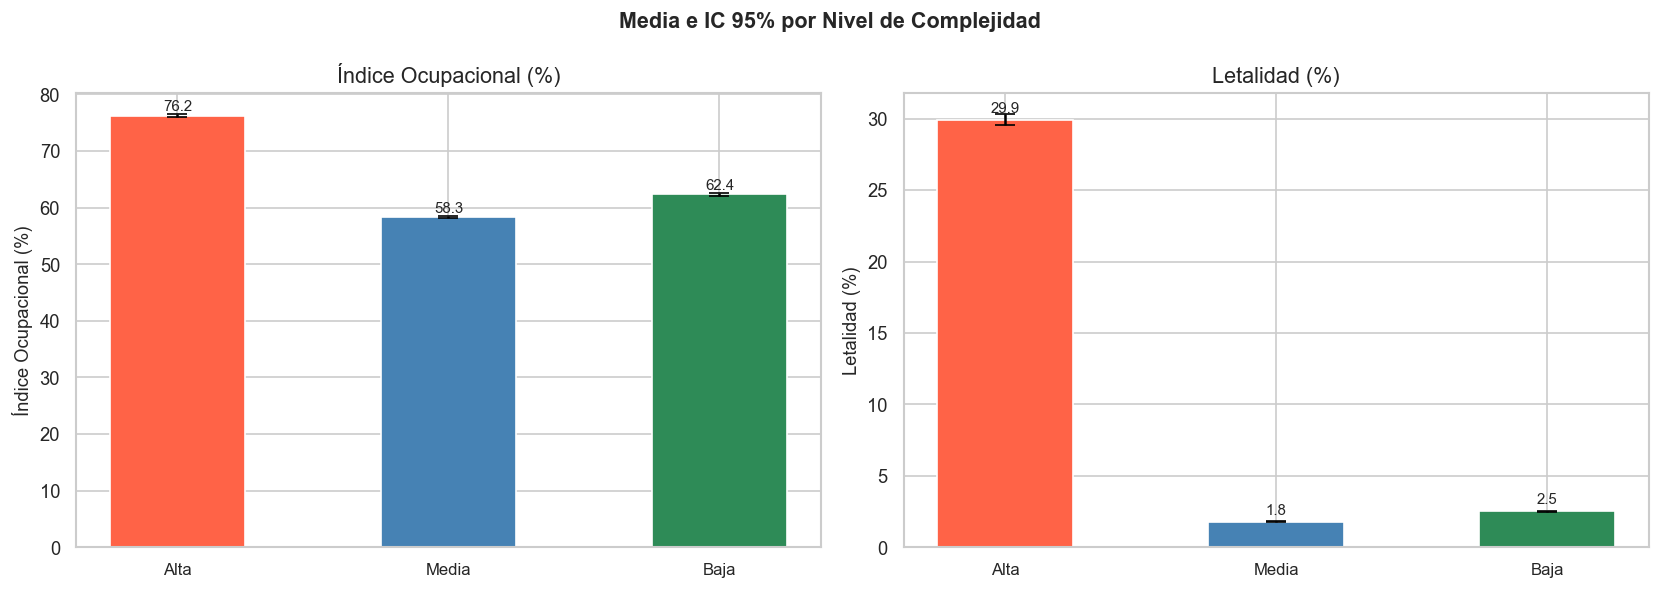

In [33]:
# Gráfico de barras con IC 95% por complejidad para indicadores clave
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Media e IC 95% por Nivel de Complejidad', fontsize=13, fontweight='bold')

colors = {'Alta complejidad': 'tomato', 'Media complejidad': 'steelblue', 'Baja complejidad': 'seagreen'}
x = range(len(grupos))

for ax, col, label in [
    (axes[0], 'INDICE_OCUPACIONAL', 'Índice Ocupacional (%)'),
    (axes[1], 'LETALIDAD',          'Letalidad (%)'),
]:
    medias  = [df[df['COMPLEJIDAD'] == g][col].mean() for g in grupos]
    ic_sups = []
    ic_infs = []
    for g in grupos:
        sub = df[df['COMPLEJIDAD'] == g][col].dropna()
        n   = len(sub)
        ee  = sub.std(ddof=1) / (n**0.5)
        t_c = scipy_stats.t.ppf(0.975, df=n-1)
        ic_infs.append(sub.mean() - t_c * ee)
        ic_sups.append(sub.mean() + t_c * ee)

    errs_inf = [m - i for m, i in zip(medias, ic_infs)]
    errs_sup = [s - m for m, s in zip(medias, ic_sups)]

    bars = ax.bar(x, medias, color=[colors[g] for g in grupos],
                  edgecolor='white', width=0.5, yerr=[errs_inf, errs_sup],
                  capsize=6, error_kw={'elinewidth': 1.5, 'ecolor': 'black'})
    ax.set_xticks(x)
    ax.set_xticklabels([g.replace(' complejidad','') for g in grupos], fontsize=10)
    ax.set_title(label)
    ax.set_ylabel(label)
    for bar, m in zip(bars, medias):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{m:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 9.5 Gráficos de dispersión — Relaciones entre variables

Los gráficos de dispersión permiten identificar visualmente patrones de correlación entre pares de indicadores.

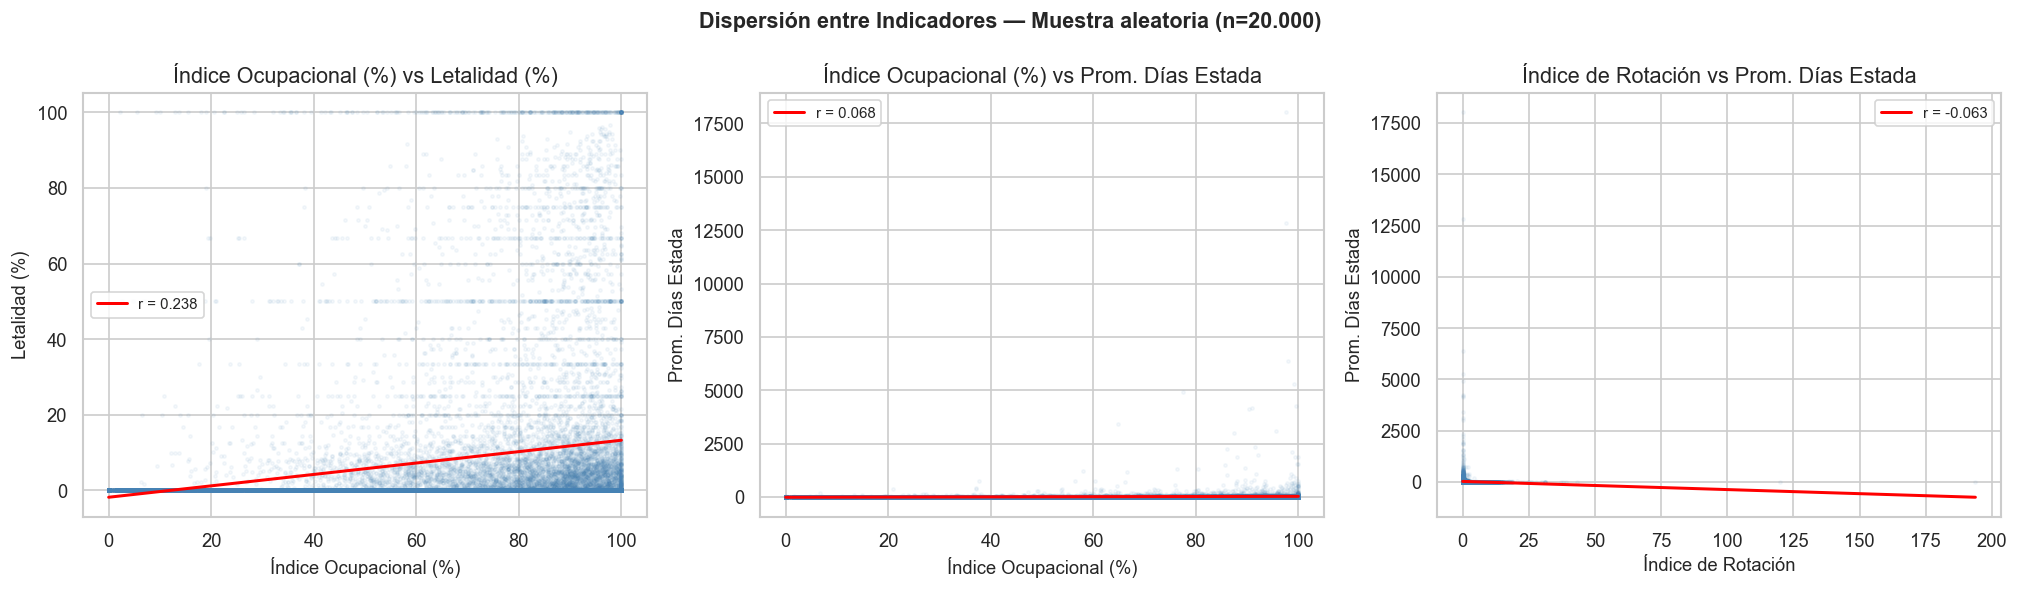

In [34]:
# Scatter plots entre pares de indicadores clave
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Dispersión entre Indicadores — Muestra aleatoria (n=20.000)', fontsize=13, fontweight='bold')

# Muestra para no saturar
sample = df.sample(min(20000, len(df)), random_state=42)

pares = [
    ('INDICE_OCUPACIONAL', 'LETALIDAD',           'Índice Ocupacional (%)', 'Letalidad (%)'),
    ('INDICE_OCUPACIONAL', 'PROMEDIO_DIAS_ESTADA', 'Índice Ocupacional (%)', 'Prom. Días Estada'),
    ('INDICE_ROTACION',    'PROMEDIO_DIAS_ESTADA', 'Índice de Rotación',     'Prom. Días Estada'),
]

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, pares):
    ax.scatter(sample[xcol], sample[ycol],
               alpha=0.05, s=4, color='steelblue')
    # línea de tendencia
    mask = sample[[xcol, ycol]].dropna().index
    m, b = np.polyfit(sample.loc[mask, xcol], sample.loc[mask, ycol], 1)
    xs = np.linspace(sample[xcol].min(), sample[xcol].max(), 200)
    r = sample[xcol].corr(sample[ycol])
    ax.plot(xs, m*xs + b, color='red', linewidth=1.8, label=f'r = {r:.3f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{xlabel} vs {ylabel}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 9.6 Tabla resumen consolidada de estimadores

In [35]:
# Tabla resumen final: media, IC y comparación entre grupos
print("TABLA RESUMEN CONSOLIDADA — ESTIMADORES PUNTUALES E IC 95% POR GRUPO")
print("="*75)

cols_resumen = ['INDICE_OCUPACIONAL', 'LETALIDAD', 'PROMEDIO_DIAS_ESTADA', 'INDICE_ROTACION']
labels_resumen = ['IO (%)', 'Letalidad (%)', 'Días Estada', 'Rotación']

filas = []
for grupo in ['TOTAL'] + grupos:
    sub = df if grupo == 'TOTAL' else df[df['COMPLEJIDAD'] == grupo]
    fila = {'Grupo': grupo}
    for col, lbl in zip(cols_resumen, labels_resumen):
        serie = sub[col].dropna()
        n     = len(serie)
        media = serie.mean()
        std   = serie.std(ddof=1)
        ee    = std / (n**0.5)
        t_c   = scipy_stats.t.ppf(0.975, df=n-1)
        margen = t_c * ee
        fila[f'{lbl} media'] = f'{media:.2f}'
        fila[f'{lbl} IC95'] = f'[{media-margen:.2f}, {media+margen:.2f}]'
    filas.append(fila)

df_resumen_final = pd.DataFrame(filas)
display(df_resumen_final)

TABLA RESUMEN CONSOLIDADA — ESTIMADORES PUNTUALES E IC 95% POR GRUPO


,Grupo,IO (%) media,IO (%) IC95,Letalidad (%) media,Letalidad (%) IC95,Días Estada media,Días Estada IC95,Rotación media,Rotación IC95
0,TOTAL,63.19,"[63.04, 63.33]",7.70,"[7.61, 7.80]",18.83,"[18.18, 19.48]",2.82,"[2.81, 2.84]"
1,Alta complejidad,76.21,"[75.98, 76.44]",29.94,"[29.58, 30.30]",31.25,"[30.75, 31.75]",1.08,"[1.07, 1.10]"
2,Media complejidad,58.32,"[58.09, 58.56]",1.78,"[1.73, 1.83]",21.24,"[19.95, 22.52]",2.94,"[2.92, 2.96]"
3,Baja complejidad,62.37,"[62.12, 62.63]",2.52,"[2.48, 2.56]",6.82,"[6.45, 7.20]",3.78,"[3.75, 3.81]"
